# Bayesian Network Example: Cardiovascular Disease
## A Simple, Guided Real-Data Example

### Purpose of this notebook

This notebook is meant to accompany the written document on **Bayesian Networks**. The goal is not to cover every technical detail, but to show in a clear way how the main ideas work in a real example.

In particular, the notebook is organised around three questions:

1. What variables are we studying and how are they related?
2. How can we represent these relationships with a Bayesian Network?
3. Once the model is fitted, what can we learn from it?

### General idea

We work with a cardiovascular dataset and propose a **fixed directed acyclic graph (DAG)** based on simple medical knowledge. Then, instead of estimating one large model at once, we estimate the main conditional relationships one by one using Bayesian methods with **PyMC** and **MCMC**.

This gives us:

- a concrete example of a Bayesian Network,
- posterior distributions for the main relationships in the graph,
- and a way to study how changes in one variable can affect cardiovascular risk.

The important modelling idea is that we do **not** fit one giant equation for all variables at once. Once the DAG is fixed, a Bayesian Network writes the joint distribution as a product of **local conditional models**:

$$P(X_1, \dots, X_p) = \prod_{j=1}^p P(X_j \mid \mathrm{Pa}(X_j)).$$

So each non-root node gets its own conditional model given its parents. In this notebook, those local pieces are:

- `bmi | weight, height, alco, active`
- `ap_hi | bmi, age, smoke`
- `ap_lo | bmi, age`
- `cholesterol | bmi, age`
- `cardio | ap_hi, ap_lo, cholesterol, gluc, age, gender`

This is why we estimate several Bayesian regressions rather than one single model. They are not unrelated equations: together they form the probabilistic structure implied by the graph.

So, if the attached report explains a Bayesian Network as a graph plus one conditional distribution for each node given its parents, then this notebook is coherent with that explanation. The only extra caution is interpretive: causal claims depend on whether the chosen DAG is substantively reasonable, not only on whether the local regressions are estimated correctly.

### How to read the notebook

The notebook is divided into four parts:

1. **Data and motivation**: load the dataset, clean it, and look at the main patterns.
2. **Network specification**: define the Bayesian Network and explain the role of each variable.
3. **Bayesian estimation**: fit the conditional models associated with the graph.
4. **Inference and interpretation**: check diagnostics, combine results, and study a few interventions.

The emphasis is on interpretation and intuition, in line with the written report.


## 0. Setup

This section imports the libraries and defines a random seed so that the analysis is reproducible.


In [1]:
# Run this cell first in Google Colab
#!pip install -q pymc arviz numpy pandas matplotlib seaborn scipy networkx

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version : 5.25.1
ArviZ version: 0.23.4


## 1. Load and Clean the Data

Before building the network, we prepare the dataset in a simple and transparent way.

What we do here:

- load the cardiovascular dataset,
- create a few useful variables such as age in years and BMI,
- remove clearly implausible observations,
- and check the final size of the cleaned sample.

This step matters because the later Bayesian models will only be as reasonable as the data we feed into them.


In [3]:
# In Google Colab, uncomment the next two lines to upload the file 
# from google.colab import files
# files.upload()

DATA_PATH = Path("cardio_train.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Download cardio_train.csv from "
        "https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset "
        "and place it in the working directory."
    )

df_raw = pd.read_csv(DATA_PATH, sep=";")
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df = df_raw.copy()

# Convert age from days to years 
df["age_years"] = (df["age"] / 365.25).round(1)

# Compute BMI 
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2

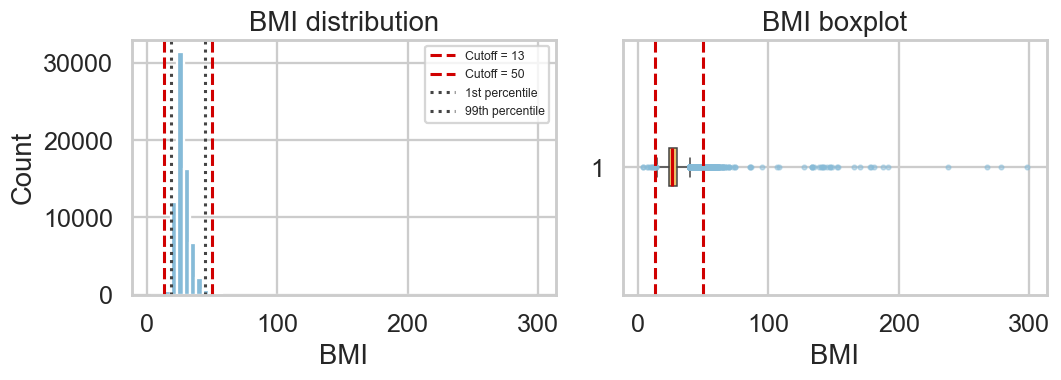

BMI summary:
count    70000.00
mean        27.56
std          6.09
min          3.47
1%          18.61
5%          20.94
50%         26.37
95%         37.39
99%         44.43
max        298.67
Name: bmi, dtype: float64


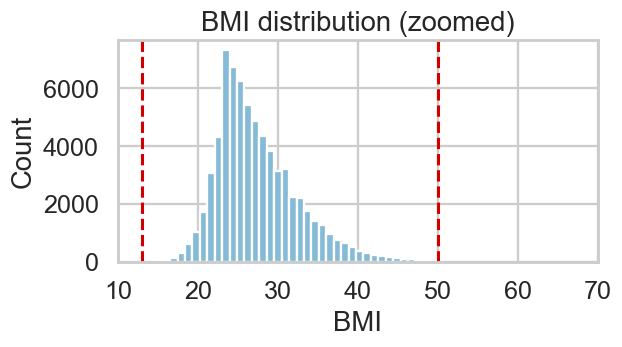

In [5]:
# Visual check of the BMI distribution to see if we need to cut out values
bmi_raw = df["bmi"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Histogram
axes[0].hist(bmi_raw, bins=60, color="#86BBD8", edgecolor="white")
axes[0].axvline(13, color="#D00000", linestyle="--", linewidth=2, label="Cutoff = 13")
axes[0].axvline(50, color="#D00000", linestyle="--", linewidth=2, label="Cutoff = 50")
axes[0].axvline(bmi_raw.quantile(0.01), color="#444444", linestyle=":", linewidth=2, label="1st percentile")
axes[0].axvline(bmi_raw.quantile(0.99), color="#444444", linestyle=":", linewidth=2, label="99th percentile")
axes[0].set_title("BMI distribution")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(bmi_raw, vert=False, patch_artist=True,
                boxprops=dict(facecolor="#E9C46A", color="#444444"),
                medianprops=dict(color="#D00000", linewidth=2),
                whiskerprops=dict(color="#444444"),
                capprops=dict(color="#444444"),
                flierprops=dict(marker='o', markersize=3, markerfacecolor="#86BBD8", markeredgecolor="#86BBD8", alpha=0.5))
axes[1].axvline(13, color="#D00000", linestyle="--", linewidth=2)
axes[1].axvline(50, color="#D00000", linestyle="--", linewidth=2)
axes[1].set_title("BMI boxplot")
axes[1].set_xlabel("BMI")

plt.tight_layout()
plt.show()

print("BMI summary:")
print(bmi_raw.describe(percentiles=[0.01, 0.05, 0.95, 0.99]).round(2))

plt.figure(figsize=(6, 3.5))
plt.hist(bmi_raw[bmi_raw <= 50], bins=50, color="#86BBD8", edgecolor="white")
plt.axvline(13, color="#D00000", linestyle="--", linewidth=2)
plt.axvline(50, color="#D00000", linestyle="--", linewidth=2)
plt.xlim(10, 70)
plt.title("BMI distribution (zoomed)")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


We will remove BMI values below 13 and above 50 based on:
- the plots above show no visible counts around 50
- this is coherent with typical BMI values cross checked at the reference: https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html

In [6]:
# Remove extreme BMI values 
df = df[(df["bmi"] >= 13) & (df["bmi"] <= 60)].copy()

Now we check the values of blood pressure:

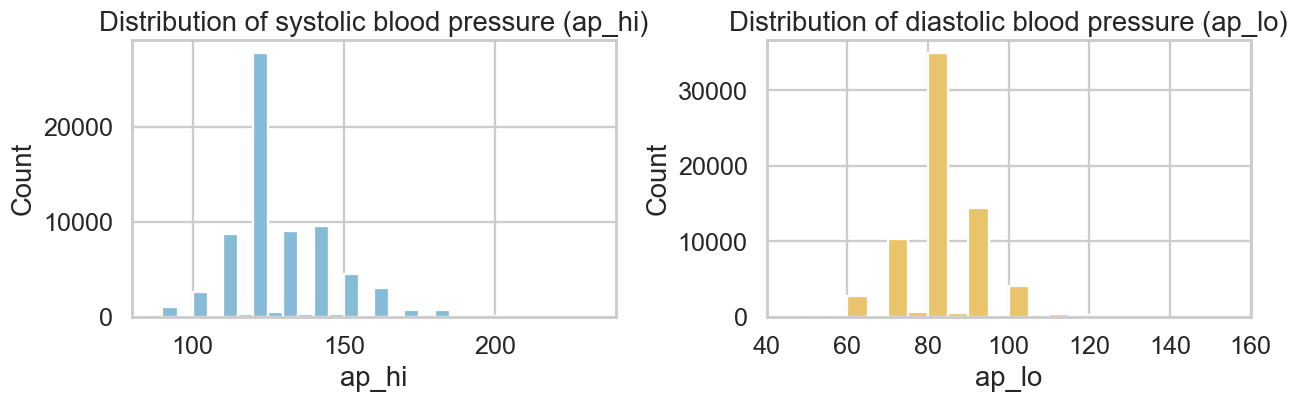

ap_hi summary:
count    70000.00
mean       128.82
std        154.01
min       -150.00
1%          90.00
5%         100.00
50%        120.00
95%        160.00
99%        180.00
max      16020.00
Name: ap_hi, dtype: float64

ap_lo summary:
count    70000.00
mean        96.63
std        188.47
min        -70.00
1%          60.00
5%          70.00
50%         80.00
95%        100.00
99%       1000.00
max      11000.00
Name: ap_lo, dtype: float64

Rows with ap_hi <= ap_lo: 1236


In [7]:
# Better visual check of blood pressure before filtering
bp_raw = df_raw.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Systolic
axes[0].hist(bp_raw["ap_hi"].dropna(), bins=np.arange(80, 241, 5),
             color="#86BBD8", edgecolor="white")
axes[0].set_title("Distribution of systolic blood pressure (ap_hi)")
axes[0].set_xlabel("ap_hi")
axes[0].set_ylabel("Count")
axes[0].set_xlim(80, 240)

# Diastolic
axes[1].hist(bp_raw["ap_lo"].dropna(), bins=np.arange(40, 161, 5),
             color="#E9C46A", edgecolor="white")
axes[1].set_title("Distribution of diastolic blood pressure (ap_lo)")
axes[1].set_xlabel("ap_lo")
axes[1].set_ylabel("Count")
axes[1].set_xlim(40, 160)

plt.tight_layout()
plt.show()

print("ap_hi summary:")
print(bp_raw["ap_hi"].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).round(2))

print("\nap_lo summary:")
print(bp_raw["ap_lo"].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).round(2))

print("\nRows with ap_hi <= ap_lo:", (bp_raw["ap_hi"] <= bp_raw["ap_lo"]).sum())


Considering the blood pressure percentiles, we cut off at the following values:
- ap_hi: 
    - minimum value = 70
        - from the dataset: 1% corresponds to 90, but there are non valid values like <=0
        - as per https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings the minimum value is "less than 120" so 70 is considered a reasonable value
    - maximum value = 240
        - from the dataset: 99% corresponds to 180
        - as per https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings the maximum value is "higher than 180" so 240 is a reasonable value

- api_lo:
    - minimum value = 40
        - from the dataset: 1% corresponds to 60, but there are non valid values like <=0
        - as per https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings the minimum value is "less than 80" so 40 is considered a reasonable value
    - maximum value = 200
        - from the dataset: 99% corresponds to 180
        - as per https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings the maximum value is "higher than 120" so 200 is a reasonable value


In [8]:
# Remove physiologically impossible blood pressure values
df = df[
    (df["ap_hi"] >= 70) & (df["ap_hi"] <= 240) &
    (df["ap_lo"] >= 40) & (df["ap_lo"] <= 200) &
    (df["ap_hi"] > df["ap_lo"]) #remove entries in which ap_hi<ap_lo (impossible)
].copy()

In [9]:
print(f"Clean shape: {df.shape}")
print(f"Removed {len(df_raw) - len(df):,} outlier rows ({(len(df_raw) - len(df))/len(df_raw)*100:.1f}%)")
print("\nClass balance:")
print(df["cardio"].value_counts(normalize=True).round(3))

Clean shape: (68601, 15)
Removed 1,399 outlier rows (2.0%)

Class balance:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


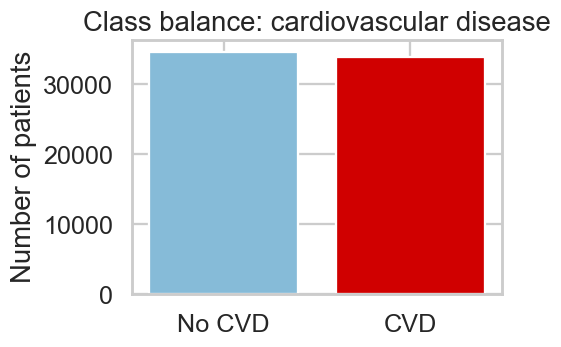

In [10]:
class_counts = df["cardio"].value_counts().sort_index()

plt.figure(figsize=(5, 3.5))
plt.bar(["No CVD", "CVD"], class_counts.values, color=["#86BBD8", "#D00000"])
plt.title("Class balance: cardiovascular disease")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()

The dataset has almost equal proportion between cardiovascular and non-cardiovascular patients.

In [11]:
print(df[["age_years", "bmi", "ap_hi", "ap_lo", "cholesterol", "gluc",
          "smoke", "alco", "active", "cardio"]].describe().round(2))

       age_years       bmi     ap_hi     ap_lo  cholesterol      gluc  \
count   68601.00  68601.00  68601.00  68601.00     68601.00  68601.00   
mean       53.29     27.45    126.67     81.31         1.36      1.23   
std         6.76      5.21     16.69      9.45         0.68      0.57   
min        29.60     13.49     70.00     40.00         1.00      1.00   
25%        48.30     23.88    120.00     80.00         1.00      1.00   
50%        53.90     26.35    120.00     80.00         1.00      1.00   
75%        58.40     30.12    140.00     90.00         2.00      1.00   
max        64.90     60.00    240.00    182.00         3.00      3.00   

          smoke      alco   active    cardio  
count  68601.00  68601.00  68601.0  68601.00  
mean       0.09      0.05      0.8      0.49  
std        0.28      0.22      0.4      0.50  
min        0.00      0.00      0.0      0.00  
25%        0.00      0.00      1.0      0.00  
50%        0.00      0.00      1.0      0.00  
75%        0.

Now all the values of other variables are reasonable, so we end here the cleaning of the dataset.

## 2. First Look at the Data

Before fitting the Bayesian Network, it is useful to inspect the main variables and see whether the data already suggest sensible relationships.

The figures below are descriptive only, with the goal to build intuition.


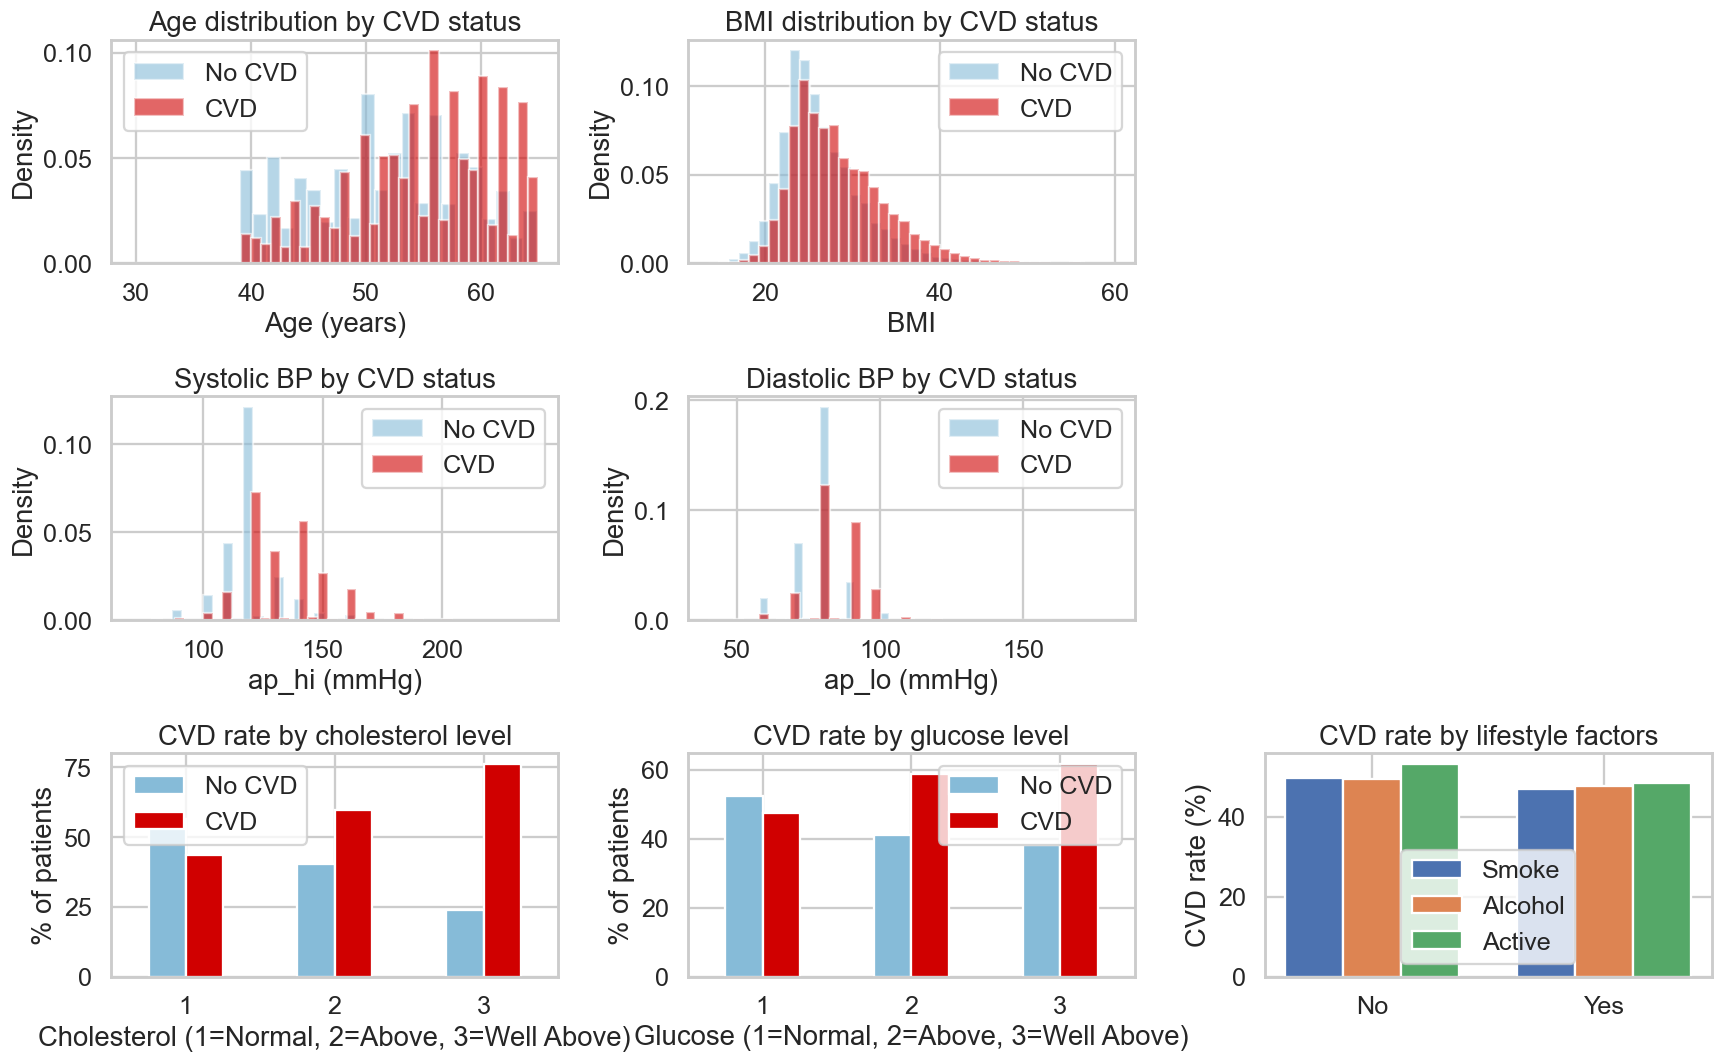

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

# Turn off the two unused panels
axes[0, 2].axis("off")
axes[1, 2].axis("off")

# Row 1, Col 1: Age distribution by cardio
for grp, col, lbl in [(0, "#86BBD8", "No CVD"), (1, "#D00000", "CVD")]:
    axes[0, 0].hist(df[df["cardio"] == grp]["age_years"], bins=30,
                    alpha=0.6, color=col, label=lbl, density=True)
axes[0, 0].set_title("Age distribution by CVD status")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# Row 1, Col 2: BMI distribution by cardio
for grp, col, lbl in [(0, "#86BBD8", "No CVD"), (1, "#D00000", "CVD")]:
    axes[0, 1].hist(df[df["cardio"] == grp]["bmi"], bins=40,
                    alpha=0.6, color=col, label=lbl, density=True)
axes[0, 1].set_title("BMI distribution by CVD status")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# Row 2, Col 1: Systolic BP by cardio
for grp, col, lbl in [(0, "#86BBD8", "No CVD"), (1, "#D00000", "CVD")]:
    axes[1, 0].hist(df[df["cardio"] == grp]["ap_hi"], bins=40,
                    alpha=0.6, color=col, label=lbl, density=True)
axes[1, 0].set_title("Systolic BP by CVD status")
axes[1, 0].set_xlabel("ap_hi (mmHg)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# Row 2, Col 2: Diastolic BP by cardio
for grp, col, lbl in [(0, "#86BBD8", "No CVD"), (1, "#D00000", "CVD")]:
    axes[1, 1].hist(df[df["cardio"] == grp]["ap_lo"], bins=40,
                    alpha=0.6, color=col, label=lbl, density=True)
axes[1, 1].set_title("Diastolic BP by CVD status")
axes[1, 1].set_xlabel("ap_lo (mmHg)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

# Row 3, Col 1: Cholesterol by cardio
chol_cardio = df.groupby(["cholesterol", "cardio"]).size().unstack(fill_value=0)
chol_pct = chol_cardio.div(chol_cardio.sum(axis=1), axis=0) * 100
chol_pct.plot(kind="bar", ax=axes[2, 0], color=["#86BBD8", "#D00000"], rot=0)
axes[2, 0].set_title("CVD rate by cholesterol level")
axes[2, 0].set_xlabel("Cholesterol (1=Normal, 2=Above, 3=Well Above)")
axes[2, 0].set_ylabel("% of patients")
axes[2, 0].legend(["No CVD", "CVD"])

# Row 3, Col 2: Glucose by cardio
gluc_cardio = df.groupby(["gluc", "cardio"]).size().unstack(fill_value=0)
gluc_pct = gluc_cardio.div(gluc_cardio.sum(axis=1), axis=0) * 100
gluc_pct.plot(kind="bar", ax=axes[2, 1], color=["#86BBD8", "#D00000"], rot=0)
axes[2, 1].set_title("CVD rate by glucose level")
axes[2, 1].set_xlabel("Glucose (1=Normal, 2=Above, 3=Well Above)")
axes[2, 1].set_ylabel("% of patients")
axes[2, 1].legend(["No CVD", "CVD"])

# Row 3, Col 3: Smoking / alcohol / activity by cardio
lifestyle_rates = {
    "Smoke": df.groupby("smoke")["cardio"].mean(),
    "Alcohol": df.groupby("alco")["cardio"].mean(),
    "Active": df.groupby("active")["cardio"].mean(),
}
x = np.arange(2)
width = 0.25
for i, (label, rates) in enumerate(lifestyle_rates.items()):
    axes[2, 2].bar(x + i * width, rates.values * 100, width, label=label)

axes[2, 2].set_xticks(x + width)
axes[2, 2].set_xticklabels(["No", "Yes"])
axes[2, 2].set_title("CVD rate by lifestyle factors")
axes[2, 2].set_ylabel("CVD rate (%)")
axes[2, 2].legend()

fig.tight_layout()
plt.show()


Expected factors:
- the cardiovascular patients are more concentrated on people with age >55.
- there is an opposite trend of cholesterol/glucose level between cardiovascular and non-cardiovascular patients:
    - the amount of cardiovascular patients increases with the level of cholesterol/glucose
    - while the amount of non-cardiovascular patients decreases with those levels


It is interesting to notice from the last subplot that the amount of cardiovascular and non-cardiovascular patients is similar, irrespective of smonking/non-smoking, alcohol/non-alchol and physically active/not-active. This may show that there is no direct correlation between these factors and the disease, or it may depend on how the data was collected (e.g. purposely balanced).

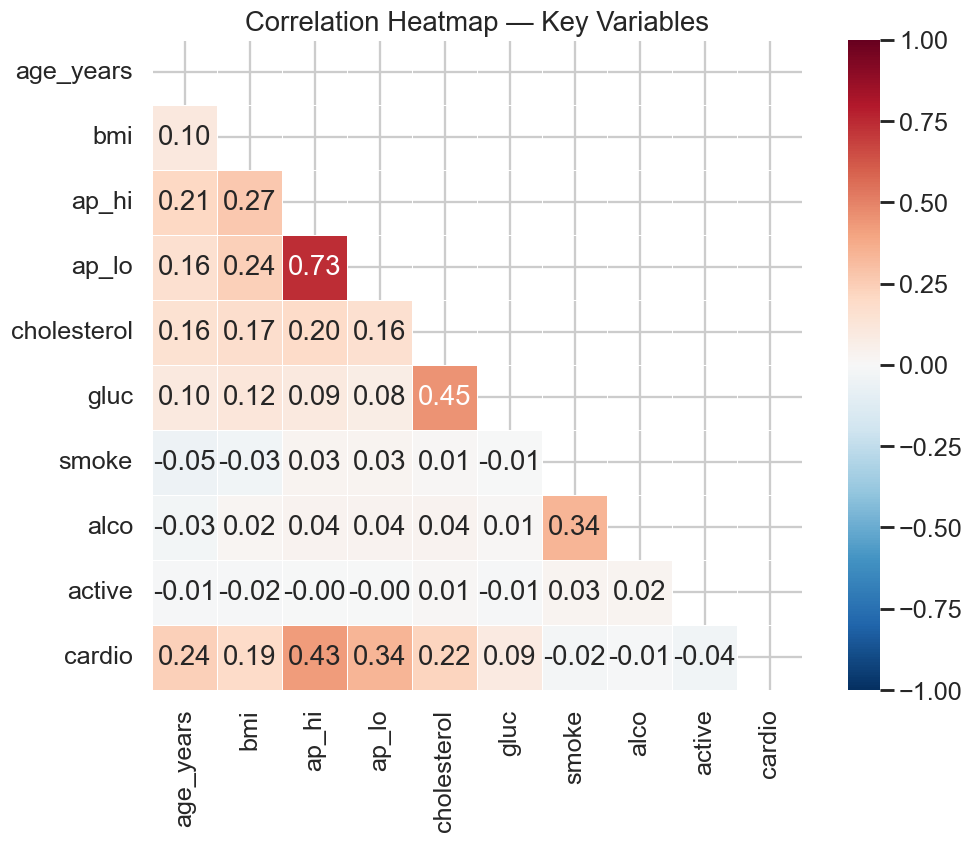

In [13]:
# Correlation heatmap
numeric_cols = ["age_years", "bmi", "ap_hi", "ap_lo", "cholesterol", "gluc",
                "smoke", "alco", "active", "cardio"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Key Variables")
plt.tight_layout()
plt.show()

## 3. Proposed Bayesian Network

A Bayesian Network combines two ingredients:

- a **graph**, which tells us which variables directly depend on which others,
- and a set of **conditional probability models**, one for each non-root node.

Here we do **not** learn the graph automatically from data. Instead, we specify it in advance as causal inference, using simple domain knowledge (exogenous knowledge).

This means the conditional models below should be read as the local building blocks of one Bayesian Network. Each model captures a direct parent-child relation in the DAG, and the whole collection approximates the full joint behaviour of the system.

The graph should be read from left to right:

- some variables are treated as starting points or background variables,
- some variables act as intermediate quantities,
- and `cardio` is the final outcome of interest.


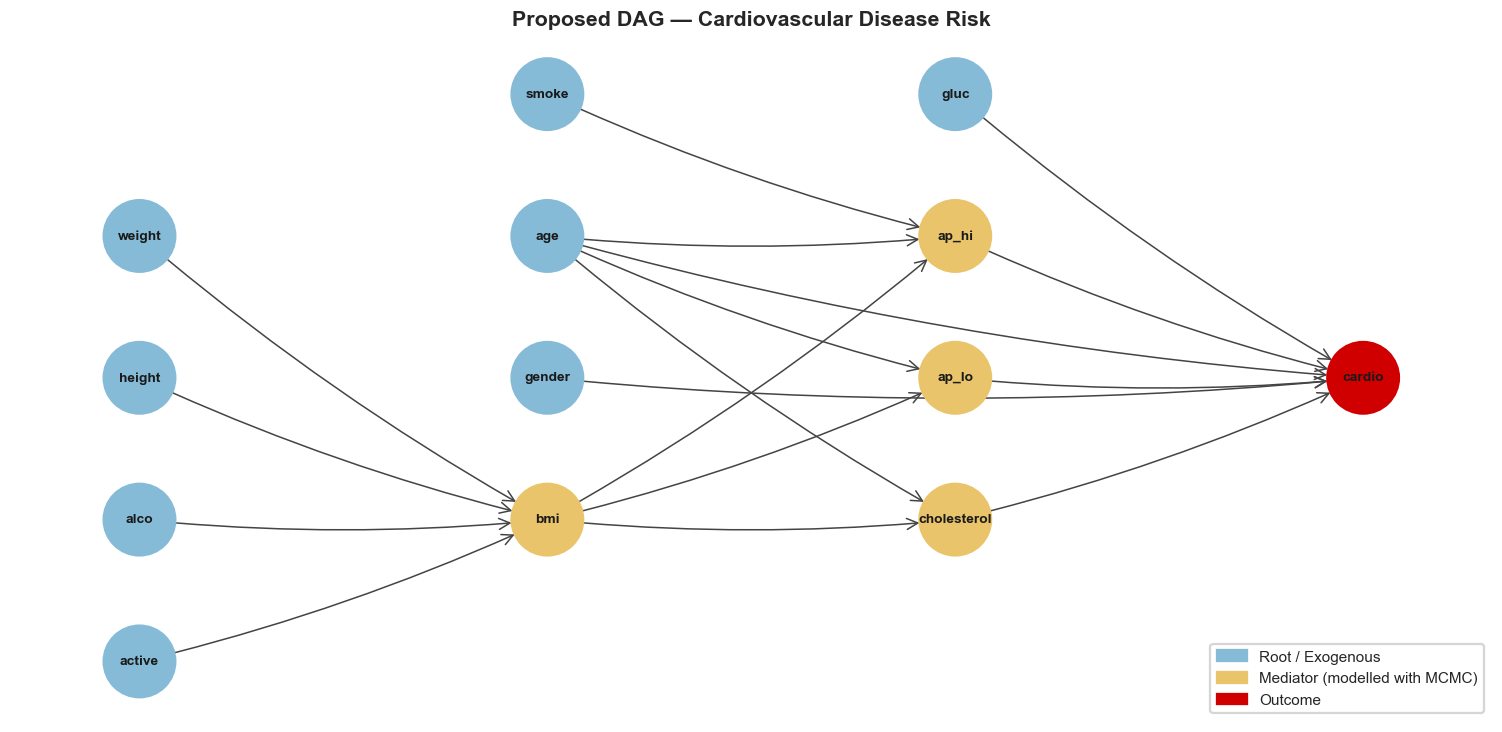

DAG has 13 nodes, 17 edges
Is DAG (acyclic): True
Topological order: ['weight', 'height', 'alco', 'active', 'age', 'smoke', 'gluc', 'gender', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'cardio']


In [14]:
# Define DAG edges 
DAG_EDGES = [
    # Demographic → BMI
    ("weight",  "bmi"),
    ("height",  "bmi"),
    ("alco",    "bmi"),
    ("active",  "bmi"),
    # Demographic + lifestyle → Systolic BP
    ("bmi",     "ap_hi"),
    ("age",     "ap_hi"),
    ("smoke",   "ap_hi"),
    # age → diastolic BP
    ("bmi",     "ap_lo"),
    ("age",     "ap_lo"),
    # BMI + age → Cholesterol
    ("bmi",     "cholesterol"),
    ("age",     "cholesterol"),
    # Proximal causes → Cardio outcome
    ("ap_hi",   "cardio"),
    ("ap_lo",   "cardio"),
    ("cholesterol", "cardio"),
    ("gluc",    "cardio"),
    ("age",     "cardio"),
    ("gender",  "cardio"),
]

G = nx.DiGraph()
G.add_edges_from(DAG_EDGES)

# Node categories for colouring 
ROOT_NODES      = {"weight", "height", "alco", "active", "smoke", "age", "gender", "gluc"}
MEDIATOR_NODES  = {"bmi", "ap_hi", "ap_lo", "cholesterol"}
OUTCOME_NODES   = {"cardio"}

color_map = []
for node in G.nodes():
    if node in OUTCOME_NODES:
        color_map.append("#D00000")
    elif node in MEDIATOR_NODES:
        color_map.append("#E9C46A")
    else:
        color_map.append("#86BBD8")

# Layout 
pos = {
    "weight": (0, 3), "height": (0, 2), "alco": (0, 1), "active": (0, 0),
    "smoke":  (2, 4), "age":    (2, 3), "gender": (2, 2), "gluc": (4, 4),
    "bmi":    (2, 1),
    "ap_hi":  (4, 3), "ap_lo":  (4, 2), "cholesterol": (4, 1),
    "cardio": (6, 2),
}

fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx(
    G, pos=pos, ax=ax,
    node_color=color_map, node_size=2200,
    font_size=9, font_weight="bold",
    edge_color="#444444", arrows=True,
    arrowsize=18, arrowstyle="->",
    connectionstyle="arc3,rad=0.05",
)

legend_handles = [
    mpatches.Patch(color="#86BBD8", label="Root / Exogenous"),
    mpatches.Patch(color="#E9C46A", label="Mediator (modelled with MCMC)"),
    mpatches.Patch(color="#D00000", label="Outcome"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
ax.set_title("Proposed DAG — Cardiovascular Disease Risk", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"DAG has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Is DAG (acyclic): {nx.is_directed_acyclic_graph(G)}")
print(f"Topological order: {list(nx.topological_sort(G))}")

The blue nodes represent **exogenous (root) variables**, that is, variables with no parents in the proposed DAG. They are treated as observed variables and are not modeled as being generated by other nodes in the network. The yellow nodes represent **mediating variables**, whose conditional distributions are specified as functions of their parent nodes. The red node, `cardio`, is the **outcome variable** and is modeled conditionally on its direct predictors. Within this Bayesian framework, MCMC is used to estimate the posterior distributions of the parameters governing the mediator and outcome models, while the exogenous variables enter the model as fixed observed inputs.


In [15]:
node_summary = pd.DataFrame([
    {"Variable": "weight", "Role in network": "Root variable", "Direct children": "bmi"},
    {"Variable": "height", "Role in network": "Root variable", "Direct children": "bmi"},
    {"Variable": "alco", "Role in network": "Root variable", "Direct children": "bmi"},
    {"Variable": "active", "Role in network": "Root variable", "Direct children": "bmi"},
    {"Variable": "smoke", "Role in network": "Root variable", "Direct children": "ap_hi"},
    {"Variable": "age", "Role in network": "Root variable", "Direct children": "ap_hi, ap_lo, cholesterol, cardio"},
    {"Variable": "gender", "Role in network": "Root variable", "Direct children": "cardio"},
    {"Variable": "gluc", "Role in network": "Root variable", "Direct children": "cardio"},
    {"Variable": "bmi", "Role in network": "Intermediate variable", "Direct children": "ap_hi, ap_lo, cholesterol"},
    {"Variable": "ap_hi", "Role in network": "Intermediate variable", "Direct children": "cardio"},
    {"Variable": "ap_lo", "Role in network": "Intermediate variable", "Direct children": "cardio"},
    {"Variable": "cholesterol", "Role in network": "Intermediate variable", "Direct children": "cardio"},
    {"Variable": "cardio", "Role in network": "Outcome", "Direct children": "-"},
])

node_summary


,Variable,Role in network,Direct children
0,weight,Root variable,bmi
1,height,Root variable,bmi
2,alco,Root variable,bmi
3,active,Root variable,bmi
4,smoke,Root variable,ap_hi
5,age,Root variable,"ap_hi, ap_lo, cholesterol, cardio"
6,gender,Root variable,cardio
7,gluc,Root variable,cardio
8,bmi,Intermediate variable,"ap_hi, ap_lo, cholesterol"
9,ap_hi,Intermediate variable,cardio


## 4. Prepare the Variables for Bayesian Estimation

The models in the next sections are fitted more easily if continuous variables are placed on a comparable scale.

What is done here:

- continuous variables are **standardised** to mean 0 and standard deviation 1,
- binary variables are **centred** by subtracting their mean,
- the ordinal cholesterol outcome is recoded to the format required by PyMC.

Interpretation note:

- a coefficient on a standardised variable is the expected change associated with a one-standard-deviation increase --> for a standardized variable, +1 means “one standard deviation above the average”
- a coefficient on a centred binary variable compares the two groups while improving numerical stability --> for a centered binary variable like smoke, the coefficient still represents the difference between smokers and non-smokers, but the coding is shifted around the mean to help computation.


In [16]:
# Subsample for faster MCMC (increase N for production) 
N_SAMPLE = 8_000  # set to len(df) for full dataset (slow)
df_model = df.sample(n=N_SAMPLE, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Modelling on {len(df_model):,} rows")

def standardise(series):
    """Return z-scored array + (mean, std) for back-transformation."""
    mu, sigma = series.mean(), series.std()
    return (series - mu).to_numpy(dtype=float) / sigma, mu, sigma

# Standardise continuous inputs
age_z,    age_mu,    age_sd    = standardise(df_model["age_years"])
weight_z, weight_mu, weight_sd = standardise(df_model["weight"])
height_z, height_mu, height_sd = standardise(df_model["height"])
bmi_z,    bmi_mu,    bmi_sd    = standardise(df_model["bmi"])
ap_hi_z,  ap_hi_mu,  ap_hi_sd  = standardise(df_model["ap_hi"])
ap_lo_z,  ap_lo_mu,  ap_lo_sd  = standardise(df_model["ap_lo"])

# Binary / ordinal inputs — centre but don't scale
smoke_c  = df_model["smoke"].to_numpy(dtype=float)  - df_model["smoke"].mean()
alco_c   = df_model["alco"].to_numpy(dtype=float)   - df_model["alco"].mean()
active_c = df_model["active"].to_numpy(dtype=float) - df_model["active"].mean()
gender_c = df_model["gender"].to_numpy(dtype=float) - df_model["gender"].mean()

# Ordinal outcomes (0-indexed for PyMC)
chol_obs  = df_model["cholesterol"].to_numpy(dtype=int) - 1  # {0,1,2}
gluc_z,  gluc_mu,  gluc_sd   = standardise(df_model["gluc"].astype(float))
cardio_obs = df_model["cardio"].to_numpy(dtype=int)

print("All arrays prepared.")
print(f"Cardio prevalence in sample: {cardio_obs.mean():.3f}")

Modelling on 8,000 rows
All arrays prepared.
Cardio prevalence in sample: 0.487


In [17]:
variable_roles = pd.DataFrame([
    {"Variable": "age_years", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "ap_hi, ap_lo, cholesterol, cardio"},
    {"Variable": "weight", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "bmi"},
    {"Variable": "height", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "bmi"},
    {"Variable": "bmi", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "ap_hi, ap_lo, cholesterol"},
    {"Variable": "ap_hi", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "cardio"},
    {"Variable": "ap_lo", "Type used in model": "Continuous", "Preparation": "Standardised (z-score)", "Used in": "cardio"},
    {"Variable": "smoke", "Type used in model": "Binary", "Preparation": "Centred by subtracting the mean", "Used in": "ap_hi"},
    {"Variable": "alco", "Type used in model": "Binary", "Preparation": "Centred by subtracting the mean", "Used in": "bmi"},
    {"Variable": "active", "Type used in model": "Binary", "Preparation": "Centred by subtracting the mean", "Used in": "bmi"},
    {"Variable": "gender", "Type used in model": "Binary", "Preparation": "Centred by subtracting the mean", "Used in": "cardio"},
    {"Variable": "gluc", "Type used in model": "Ordinal treated as numeric", "Preparation": "Standardised", "Used in": "cardio"},
    {"Variable": "cholesterol", "Type used in model": "Ordinal", "Preparation": "Re-coded to 0, 1, 2 for PyMC", "Used in": "cholesterol model"},
    {"Variable": "cardio", "Type used in model": "Binary outcome", "Preparation": "Used as observed 0/1 response", "Used in": "final outcome model"},
])

variable_roles


,Variable,Type used in model,Preparation,Used in
0,age_years,Continuous,Standardised (z-score),"ap_hi, ap_lo, cholesterol, cardio"
1,weight,Continuous,Standardised (z-score),bmi
2,height,Continuous,Standardised (z-score),bmi
3,bmi,Continuous,Standardised (z-score),"ap_hi, ap_lo, cholesterol"
4,ap_hi,Continuous,Standardised (z-score),cardio
5,ap_lo,Continuous,Standardised (z-score),cardio
6,smoke,Binary,Centred by subtracting the mean,ap_hi
7,alco,Binary,Centred by subtracting the mean,bmi
8,active,Binary,Centred by subtracting the mean,bmi
9,gender,Binary,Centred by subtracting the mean,cardio


### Modelling note

After defining the variables and their role in the DAG, we assign a probabilistic model to each node according to the type of outcome being modelled.

- `bmi`, `ap_hi`, and `ap_lo` are treated as **continuous variables** and are modelled with **Normal conditional distributions**. This is appropriate because they are continuous measurements and, after standardisation, their conditional behaviour can be described through a linear mean structure plus residual Gaussian variation.

- `cholesterol` is treated as an **ordinal variable** with three ordered categories, so it is modelled through an **ordered logistic regression** rather than a Gaussian model. This preserves the ranking of the categories without assuming equal distances between them.

- `cardio` is a **binary outcome**, so it is modelled with a **Bernoulli distribution** and a logistic link function.

- `age`, `weight`, `height`, `smoke`, `alco`, `active`, `gender`, and `gluc` are used as **observed predictors**. In particular, the continuous ones are standardised, while binary predictors are centred. They enter the conditional models as inputs and are not themselves modelled as child nodes in this network.

For the Gaussian models, the parameter `alpha` denotes the **intercept**. Because the continuous covariates are standardised and the binary covariates are centred, `alpha` represents the expected value of the response, on the standardised scale, when the predictors are at their average reference level.

## Prior Visualisation

Before fitting the conditional models, it is useful to visualise the prior distributions adopted in the network. This helps distinguish prior assumptions from posterior conclusions and clarifies how informative each specification is on the standardised scale used throughout the analysis.

The figure below summarises the main priors used for regression coefficients, residual standard deviations, and the cutpoints of the ordered logistic cholesterol model.

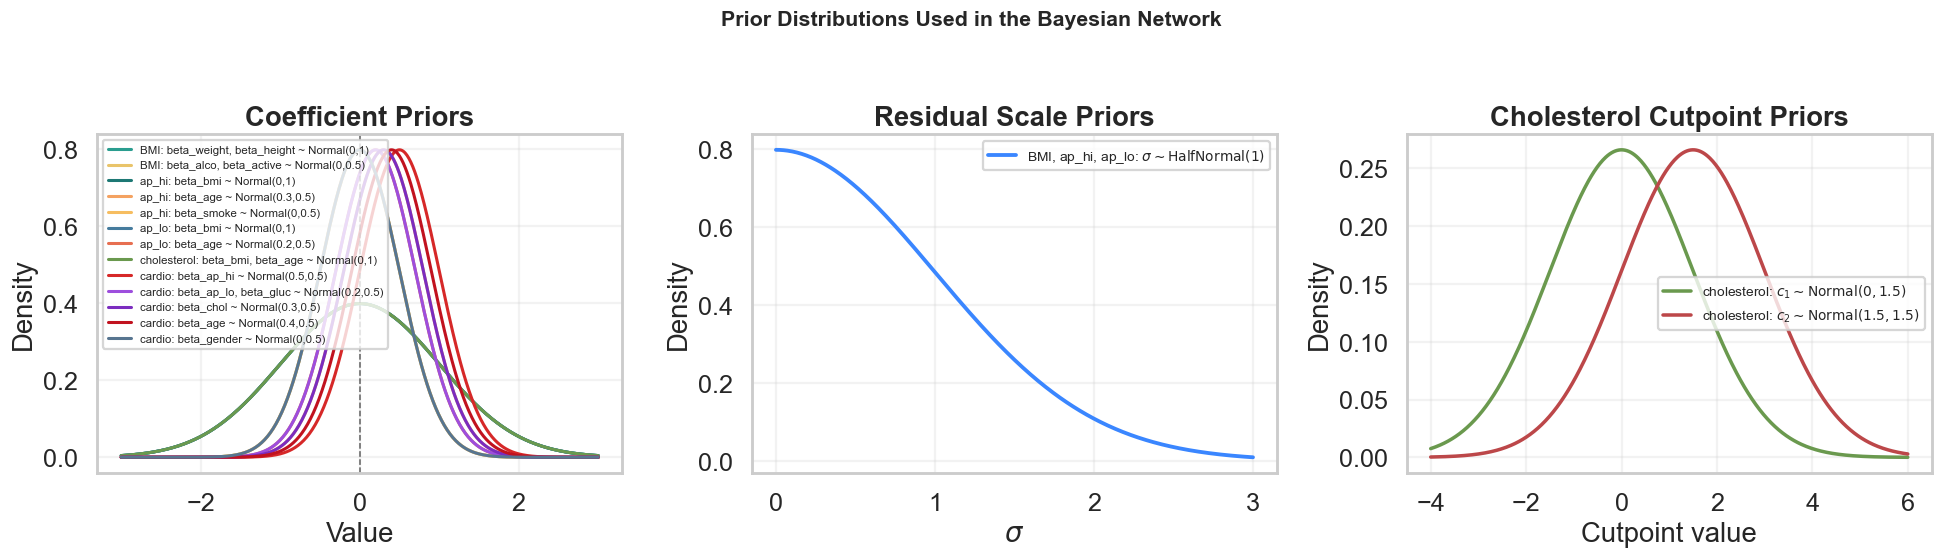

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, halfnorm

x = np.linspace(-3, 3, 500)
x_cut = np.linspace(-4, 6, 500)
x_pos = np.linspace(0, 3, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Grouped coefficient priors
grouped_priors = [
    ("BMI: beta_weight, beta_height ~ Normal(0,1)", norm.pdf(x, 0, 1), "#2A9D8F"),
    ("BMI: beta_alco, beta_active ~ Normal(0,0.5)", norm.pdf(x, 0, 0.5), "#E9C46A"),
    ("ap_hi: beta_bmi ~ Normal(0,1)", norm.pdf(x, 0, 1), "#1D7874"),
    ("ap_hi: beta_age ~ Normal(0.3,0.5)", norm.pdf(x, 0.3, 0.5), "#F4A261"),
    ("ap_hi: beta_smoke ~ Normal(0,0.5)", norm.pdf(x, 0, 0.5), "#F6BD60"),
    ("ap_lo: beta_bmi ~ Normal(0,1)", norm.pdf(x, 0, 1), "#457B9D"),
    ("ap_lo: beta_age ~ Normal(0.2,0.5)", norm.pdf(x, 0.2, 0.5), "#E76F51"),
    ("cholesterol: beta_bmi, beta_age ~ Normal(0,1)", norm.pdf(x, 0, 1), "#6A994E"),
    ("cardio: beta_ap_hi ~ Normal(0.5,0.5)", norm.pdf(x, 0.5, 0.5), "#D62828"),
    ("cardio: beta_ap_lo, beta_gluc ~ Normal(0.2,0.5)", norm.pdf(x, 0.2, 0.5), "#9D4EDD"),
    ("cardio: beta_chol ~ Normal(0.3,0.5)", norm.pdf(x, 0.3, 0.5), "#7B2CBF"),
    ("cardio: beta_age ~ Normal(0.4,0.5)", norm.pdf(x, 0.4, 0.5), "#C1121F"),
    ("cardio: beta_gender ~ Normal(0,0.5)", norm.pdf(x, 0, 0.5), "#577590"),
]

for label, density, color in grouped_priors:
    axes[0].plot(x, density, lw=2, color=color, label=label)

axes[0].axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0].set_title("Coefficient Priors", fontweight="bold")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=7.5, loc="upper left")
axes[0].grid(alpha=0.25)

# 2. Residual scale priors
axes[1].plot(
    x_pos,
    halfnorm.pdf(x_pos, scale=1),
    lw=2.5,
    color="#3A86FF",
    label=r"BMI, ap_hi, ap_lo: $\sigma \sim \mathrm{HalfNormal}(1)$"
)
axes[1].set_title("Residual Scale Priors", fontweight="bold")
axes[1].set_xlabel(r"$\sigma$")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

# 3. Cholesterol cutpoint priors
axes[2].plot(
    x_cut,
    norm.pdf(x_cut, 0.0, 1.5),
    lw=2.3,
    color="#6A994E",
    label=r"cholesterol: $c_1 \sim \mathrm{Normal}(0,1.5)$"
)
axes[2].plot(
    x_cut,
    norm.pdf(x_cut, 1.5, 1.5),
    lw=2.3,
    color="#BC4749",
    label=r"cholesterol: $c_2 \sim \mathrm{Normal}(1.5,1.5)$"
)
axes[2].set_title("Cholesterol Cutpoint Priors", fontweight="bold")
axes[2].set_xlabel("Cutpoint value")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.25)

fig.suptitle(
    "Prior Distributions Used in the Bayesian Network",
    fontsize=14,
    fontweight="bold",
    y=1.03
)
plt.tight_layout()
plt.show()

## 5. Conditional Model for BMI

In the graph, `bmi` depends directly on:

- `weight`,
- `height`,
- `alco`,
- `active`.

So the first conditional distribution we estimate is:

$$\text{BMI}_i \sim \mathcal{N}(\mu_i,\ \sigma_{\text{bmi}}^2)$$
$$\mu_i = \alpha + \beta_w\cdot w_i + \beta_h\cdot h_i + \beta_{\text{alco}}\cdot\text{alco}_i + \beta_{\text{act}}\cdot\text{active}_i$$


As mentioned, $\alpha$ is the **baseline BMI level** in the model. Since `weight` and `height` are standardised and `alco` and `active` are centred, $\alpha$ represents the expected BMI (on the standardised scale) for an individual at the average reference level of those predictors (i.e. $\alpha$ is the **starting value** of BMI in the model, before accounting for the effects of weight, height, alcohol consumption, and physical activity).

### Prior specification

Before fitting the conditional model for `bmi`, we assign prior distributions to the regression coefficients and to the residual standard deviation.

Because the continuous variables used in the model are standardised and the binary predictors are centred, the coefficients are expressed on a comparable scale. For this reason, we use priors centred at zero for regression coefficients, reflecting the idea that, before seeing the data, we do not want to assume either a positive or a negative effect.

For the main continuous predictors, such as `weight` and `height`, we use relatively broad priors of the form `Normal(0, 1)`. On the standardised scale, this allows the coefficient to vary freely, while still keeping the estimates in a plausible range.

For the binary lifestyle predictors, such as `alco` and `active`, we use slightly tighter priors, `Normal(0, 0.5)`, because these effects are expected to be more moderate and we want to avoid implausibly large coefficient values unless strongly supported by the data.

The intercept `alpha` is also assigned a `Normal(0, 1)` prior. Since the outcome is standardised, this corresponds to a prior belief that the baseline mean is likely to be near zero, but with enough flexibility to move if the data suggest otherwise.

Finally, the residual standard deviation `sigma` is assigned a `HalfNormal(1)` prior to ensure positivity while allowing a reasonably wide range of values for unexplained variation.

In [18]:
with pm.Model() as model_bmi:
    # Priors 
    alpha      = pm.Normal("alpha",      mu=0, sigma=1)
    beta_w     = pm.Normal("beta_weight", mu=0, sigma=1)
    beta_h     = pm.Normal("beta_height", mu=0, sigma=1)
    beta_alco  = pm.Normal("beta_alco",   mu=0, sigma=0.5)
    beta_act   = pm.Normal("beta_active", mu=0, sigma=0.5)
    sigma      = pm.HalfNormal("sigma",   sigma=1)

    # Linear predictor
    mu = alpha + beta_w * weight_z + beta_h * height_z + \
         beta_alco * alco_c + beta_act * active_c

    # Likelihood 
    bmi_obs_var = pm.Normal("bmi_obs", mu=mu, sigma=sigma, observed=bmi_z)

    # Sample 
    trace_bmi = pm.sample(
        draws=1500, tune=1000, chains=2, cores=1,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=True, return_inferencedata=True,
    )

print(az.summary(trace_bmi, var_names=["alpha","beta_weight","beta_height",
                                        "beta_alco","beta_active","sigma"],
                 round_to=3))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_weight, beta_height, beta_alco, beta_active, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       -0.000  0.001  -0.003    0.003        0.0      0.0  3859.708   
beta_weight  1.021  0.001   1.019    1.024        0.0      0.0  3770.923   
beta_height -0.531  0.001  -0.533   -0.528        0.0      0.0  4148.574   
beta_alco   -0.006  0.006  -0.017    0.005        0.0      0.0  4345.013   
beta_active -0.002  0.003  -0.008    0.004        0.0      0.0  3540.981   
sigma        0.121  0.001   0.120    0.123        0.0      0.0  3998.065   

             ess_tail  r_hat  
alpha        1765.996  1.002  
beta_weight  2514.779  1.000  
beta_height  2506.758  1.000  
beta_alco    2197.037  1.000  
beta_active  2060.035  1.000  
sigma        2254.584  1.002  


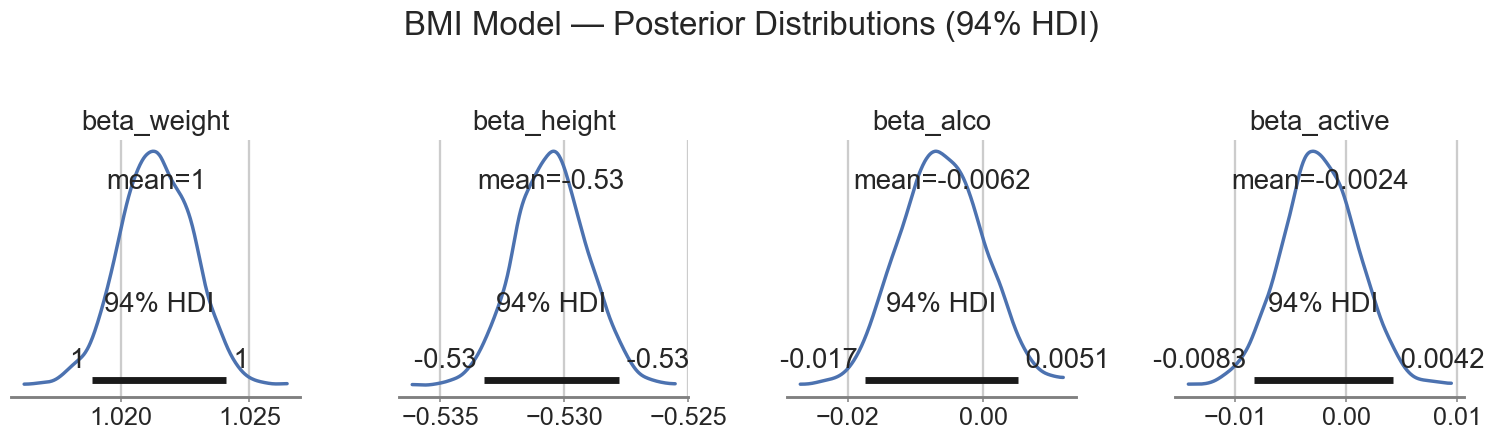

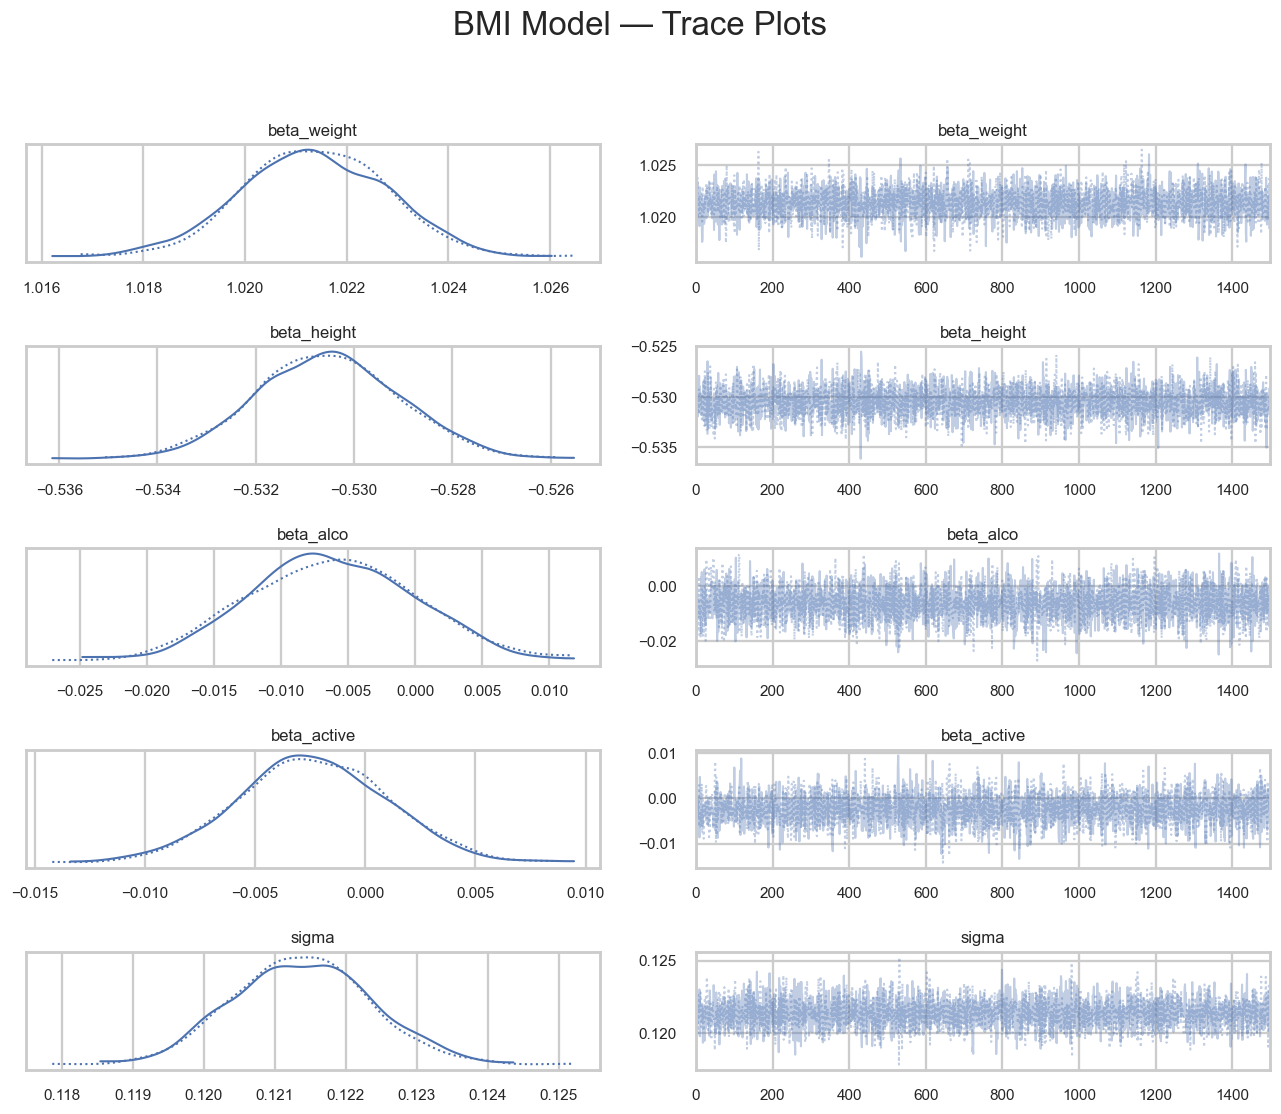

In [19]:
az.plot_posterior(trace_bmi,
                  var_names=["beta_weight","beta_height","beta_alco","beta_active"],
                  hdi_prob=0.94, figsize=(14, 4))
plt.suptitle("BMI Model — Posterior Distributions (94% HDI)", y=1.02)
plt.tight_layout()
plt.show()

az.plot_trace(trace_bmi,
              var_names=["beta_weight","beta_height","beta_alco","beta_active","sigma"])
plt.suptitle("BMI Model — Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### Observations and Conclusion: BMI Model

- `weight` has a very strong positive posterior association with BMI (`beta_weight ≈ 1.021`, 94% HDI roughly `[1.019, 1.024]`).
- `height` has a strong negative posterior association (`beta_height ≈ -0.531`, 94% HDI roughly `[-0.533, -0.528]`), which is coherent with the BMI formula because, holding weight fixed, greater height lowers BMI.
- `alco` and `active` are both centred very close to zero, and their HDIs include zero, so this model gives little evidence of a strong direct effect from those two variables once weight and height are already included.
- The residual standard deviation is small (`sigma ≈ 0.121`), which suggests that this local model explains a large share of the variation in standardised BMI.

**Conclusion.** In this network, BMI is driven mainly by anthropometric variables (weight, height) rather than by alcohol or physical activity directly. This makes BMI a plausible intermediate node through which downstream cardiovascular risk can be affected. Since this is the local conditional model for `bmi`, the coefficients should be read as direct conditional associations of BMI with its chosen parents.


## 6. Conditional Model for Systolic Blood Pressure (`ap_hi`)

According to the proposed graph, systolic blood pressure depends directly on:

- `bmi`,
- `age`,
- `smoke`.

So we estimate a Gaussian regression of the form

$$\text{ap\_hi}_i \sim \mathcal{N}(\alpha + \beta_{\text{bmi}}\cdot\text{bmi}_i + \beta_{\text{age}}\cdot\text{age}_i + \beta_{\text{smoke}}\cdot\text{smoke}_i,\ \sigma^2).$$

The main question here is whether higher BMI, older age, and smoking are associated with higher systolic blood pressure in the posterior distribution.


### Prior specification

For the systolic blood pressure model, priors are chosen to reflect both scale and substantive expectations.

The intercept `alpha` is assigned a `Normal(0,1)` prior. Since `ap_hi` is standardised, this encodes the belief that the baseline systolic pressure is likely to be near the sample average, while still allowing substantial deviation if supported by the data.

The coefficient for `bmi`, `beta_bmi`, is given a `Normal(0,1)` prior. Because `bmi` is standardised, this is a weakly informative prior that allows for either positive or negative effects of moderate size.

The coefficient for `age`, `beta_age`, is assigned a `Normal(0.3, 0.5)` prior. Unlike the previous coefficients, this prior is centred slightly above zero to reflect prior medical knowledge that older age is generally associated with higher systolic blood pressure. At the same time, the prior remains sufficiently broad to let the data update this belief.

The coefficient for `smoke`, `beta_smoke`, is assigned a `Normal(0,0.5)` prior. This reflects prior uncertainty about the direction of the effect, while slightly constraining the coefficient to moderate values unless the data provide strong evidence otherwise.

Finally, the residual standard deviation `sigma` is assigned a `HalfNormal(1)` prior to ensure positivity and to allow a flexible but regularised amount of unexplained variation around the conditional mean.

In [20]:
with pm.Model() as model_ap_hi:
    alpha      = pm.Normal("alpha",      mu=0,   sigma=1)
    beta_bmi   = pm.Normal("beta_bmi",   mu=0,   sigma=1)
    beta_age   = pm.Normal("beta_age",   mu=0.3, sigma=0.5)  # prior: positive effect
    beta_smoke = pm.Normal("beta_smoke", mu=0,   sigma=0.5)
    sigma      = pm.HalfNormal("sigma",  sigma=1)

    mu = alpha + beta_bmi * bmi_z + beta_age * age_z + beta_smoke * smoke_c

    ap_hi_obs_var = pm.Normal("ap_hi_obs", mu=mu, sigma=sigma, observed=ap_hi_z)

    trace_ap_hi = pm.sample(
        draws=1500, tune=1000, chains=2, cores=1,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=True, return_inferencedata=True,
    )

print(az.summary(trace_ap_hi,
                 var_names=["alpha","beta_bmi","beta_age","beta_smoke","sigma"],
                 round_to=3))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_bmi, beta_age, beta_smoke, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 17 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       0.000  0.011  -0.020    0.019      0.000    0.000  3751.750   
beta_bmi    0.244  0.011   0.225    0.266      0.000    0.000  3821.715   
beta_age    0.201  0.011   0.180    0.220      0.000    0.000  3318.894   
beta_smoke  0.134  0.038   0.067    0.205      0.001    0.001  4289.405   
sigma       0.943  0.007   0.930    0.958      0.000    0.000  3268.792   

            ess_tail  r_hat  
alpha       2205.440  1.000  
beta_bmi    2626.960  1.000  
beta_age    2290.057  1.002  
beta_smoke  1989.524  1.001  
sigma       2284.148  1.000  


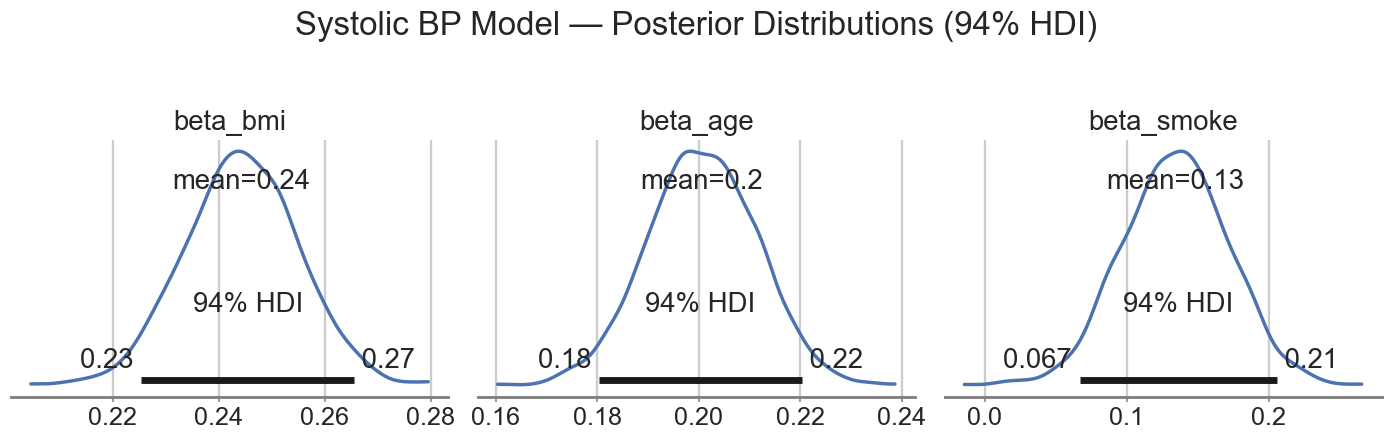

In [21]:
az.plot_posterior(trace_ap_hi,
                  var_names=["beta_bmi","beta_age","beta_smoke"],
                  hdi_prob=0.94, figsize=(13, 4))
plt.suptitle("Systolic BP Model — Posterior Distributions (94% HDI)", y=1.02)
plt.tight_layout()
plt.show()

### Observations and Conclusion: Systolic Blood Pressure Model

- Higher BMI is clearly associated with higher systolic pressure (`beta_bmi ≈ 0.244`, 94% HDI roughly `[0.225, 0.266]`).
- Older age is also clearly associated with higher systolic pressure (`beta_age ≈ 0.201`, 94% HDI roughly `[0.180, 0.220]`).
- Smoking has a smaller but still clearly positive direct association (`beta_smoke ≈ 0.134`, 94% HDI roughly `[0.067, 0.205]`).
- Comparing magnitudes, BMI appears slightly stronger than age in this local equation, while smoking matters but less strongly.

**Conclusion.** The fitted DAG is consistent with the idea that systolic blood pressure is one of the main channels through which BMI, age, and smoking propagate toward cardiovascular disease.


## 7. Conditional Model for Diastolic Blood Pressure (`ap_lo`)

For diastolic blood pressure we use a similar approach. In the graph, its direct parents are:

- `bmi`,
- `age`.

So we estimate a Gaussian regression of the form

$$\text{ap\_lo}_i \sim \mathcal{N}(\alpha + \beta_{\text{bmi}}\cdot\text{bmi}_i + \beta_{\text{age}}\cdot\text{age}_i,\ \sigma^2).$$

This section allows us to assess whether higher BMI and older age are associated with higher diastolic blood pressure, and to compare these effects with those previously found for systolic blood pressure (`ap_hi`).

### Prior specification

For the diastolic blood pressure model, the intercept `alpha` is assigned a `Normal(0,1)` prior. Since `ap_lo` is standardised, this reflects the expectation that the baseline level of the outcome is near zero on the standardised scale, while still allowing flexibility if the data suggest otherwise.

The coefficient `beta_bmi` receives a `Normal(0,1)` prior, which allows BMI to have either a positive or a negative effect of moderate size without imposing a strong prior direction.

The coefficient `beta_age` is assigned a `Normal(0.2,0.5)` prior, centred slightly above zero to reflect the expectation that older age is generally associated with higher diastolic blood pressure, while still leaving room for the data to determine the final posterior estimate.

Finally, the residual standard deviation `sigma` is given a `HalfNormal(1)` prior to ensure positivity and to allow a reasonable amount of unexplained variation around the conditional mean.

In [22]:
with pm.Model() as model_ap_lo:
    alpha    = pm.Normal("alpha",    mu=0,   sigma=1)
    beta_bmi = pm.Normal("beta_bmi", mu=0,   sigma=1)
    beta_age = pm.Normal("beta_age", mu=0.2, sigma=0.5)
    sigma    = pm.HalfNormal("sigma", sigma=1)

    mu = alpha + beta_bmi * bmi_z + beta_age * age_z

    ap_lo_obs_var = pm.Normal("ap_lo_obs", mu=mu, sigma=sigma, observed=ap_lo_z)

    trace_ap_lo = pm.sample(
        draws=1500, tune=1000, chains=2, cores=1,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=True, return_inferencedata=True,
    )

print(az.summary(trace_ap_lo,
                 var_names=["alpha","beta_bmi","beta_age","sigma"],
                 round_to=3))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_bmi, beta_age, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     0.000  0.011  -0.020    0.021        0.0      0.0  3130.406   
beta_bmi  0.220  0.011   0.201    0.241        0.0      0.0  2963.625   
beta_age  0.138  0.011   0.117    0.159        0.0      0.0  2924.518   
sigma     0.963  0.008   0.948    0.977        0.0      0.0  3485.186   

          ess_tail  r_hat  
alpha     2098.823  1.003  
beta_bmi  1975.757  1.001  
beta_age  2114.982  1.002  
sigma     2392.397  1.001  


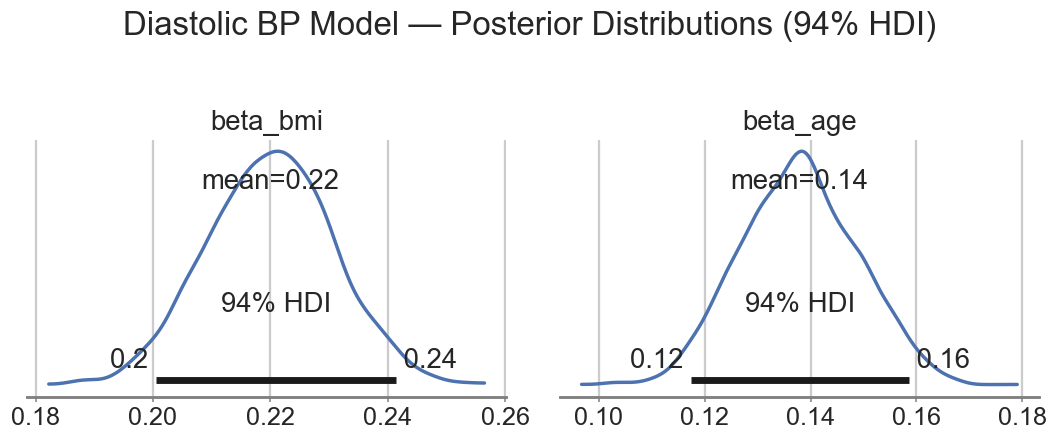

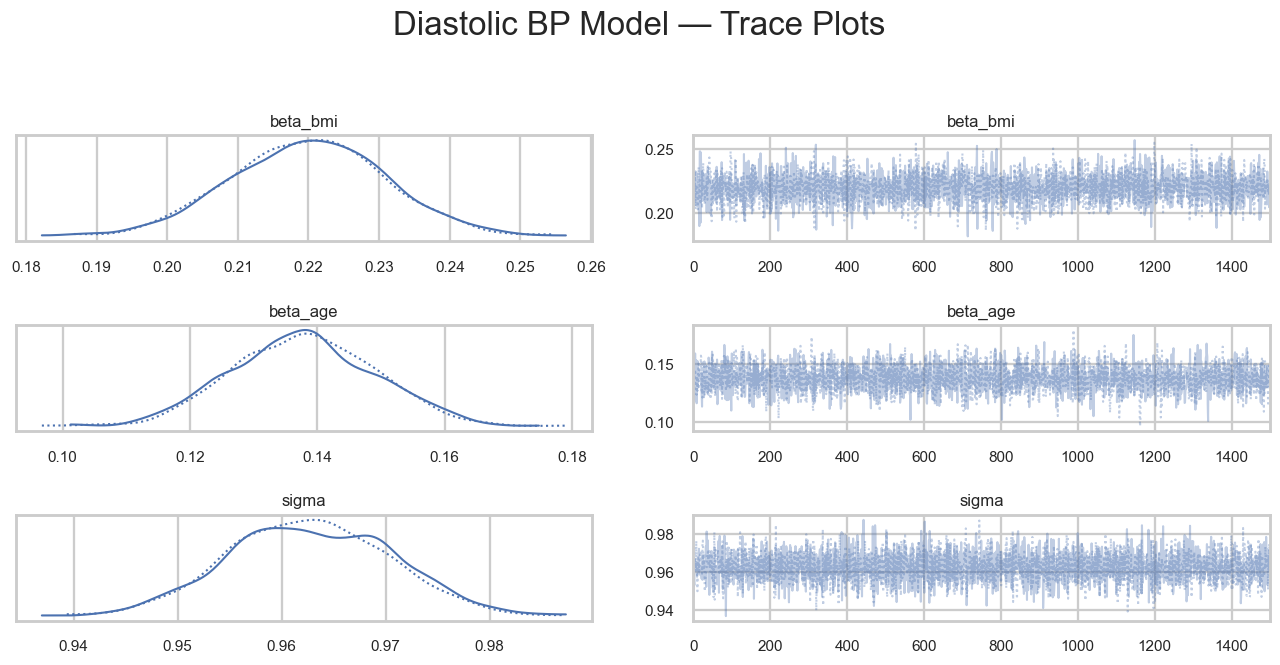

In [23]:
az.plot_posterior(trace_ap_lo,
                  var_names=["beta_bmi","beta_age"],
                  hdi_prob=0.94, figsize=(10, 4))
plt.suptitle("Diastolic BP Model — Posterior Distributions (94% HDI)", y=1.02)
plt.tight_layout()
plt.show()

az.plot_trace(trace_ap_lo,
              var_names=["beta_bmi","beta_age","sigma"])
plt.suptitle("Diastolic BP Model — Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### Observations and Conclusion: Diastolic Blood Pressure Model (check if numbers below are updated???)

- BMI again shows a clear positive association (`beta_bmi ≈ 0.220`, 94% HDI roughly `[0.201, 0.241]`).
- Age is also positive (`beta_age ≈ 0.138`, 94% HDI roughly `[0.117, 0.159]`), but weaker than in the systolic model.
- Comparing `ap_lo` with `ap_hi`, the same two predictors matter in the same direction, but their effects are a bit smaller for diastolic pressure.

**Conclusion.** This is coherent with the overall cardiovascular story in the notebook: BMI and age influence both blood-pressure components, with a somewhat stronger impact on systolic pressure.


## 8. Conditional Model for Cholesterol

Unlike `bmi`, `ap_hi`, and `ap_lo`, the variable `cholesterol` is not continuous. It is recorded as an **ordinal variable** with three ordered categories:

- `1 = normal`,
- `2 = above normal`,
- `3 = well above normal`.

According to the proposed DAG, the direct parents of `cholesterol` are:

- `bmi`,
- `age`.

For this reason, we do not use a Gaussian regression. Instead, we estimate an **ordered logistic model**, which is more appropriate for ordered categorical outcomes. Formally, we define a latent linear predictor

$$\eta_i = \beta_{\text{bmi}}\cdot\text{bmi}_i + \beta_{\text{age}}\cdot\text{age}_i,$$

and link it to the observed cholesterol category through ordered cutpoints:

$$\text{cholesterol}_i \sim \text{OrderedLogistic}(\eta_i,\ c_1, c_2),$$

where \(c_1 < c_2\) are threshold parameters separating the three cholesterol levels.

This specification allows us to assess whether higher BMI and older age are associated with a greater probability of belonging to higher cholesterol categories.


### Prior specification

For the cholesterol model, priors are assigned to the regression coefficients and to the ordered cutpoints.

The coefficients `beta_bmi` and `beta_age` are both given `Normal(0,1)` priors. Since `bmi` and `age` are standardised, these priors allow for positive or negative effects of moderate size without imposing a strong prior direction.

The cutpoints* are assigned Normal priors centred at increasing values and constrained to remain ordered. Their role is not to measure a covariate effect, but to define the boundaries between the three cholesterol categories on the latent scale of the ordered logistic model.

Overall, these priors are weakly informative: they regularise the model while still leaving the data free to determine the posterior relationships.

*In simple terms, the cutpoints are the values that separate the three cholesterol categories on an underlying continuous scale.


In [24]:
with pm.Model() as model_chol:
    beta_bmi = pm.Normal("beta_bmi", mu=0, sigma=1)
    beta_age = pm.Normal("beta_age", mu=0, sigma=1)

    # Cutpoints for ordered logistic (must be ordered)
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.array([0.0, 1.5]),
        sigma=1.5,
        transform=pm.distributions.transforms.ordered,
    )

    eta = beta_bmi * bmi_z + beta_age * age_z

    chol_obs_var = pm.OrderedLogistic(
        "chol_obs", eta=eta, cutpoints=cutpoints, observed=chol_obs
    )

    trace_chol = pm.sample(
        draws=1500, tune=1000, chains=2, cores=1,
        target_accept=0.92, random_seed=RANDOM_SEED,
        progressbar=True, return_inferencedata=True,
    )

print(az.summary(trace_chol,
                 var_names=["beta_bmi","beta_age","cutpoints"],
                 round_to=3))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta_bmi, beta_age, cutpoints]


Output()

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 81 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_bmi      0.312  0.025   0.266    0.359      0.000    0.000  2587.462   
beta_age      0.341  0.027   0.290    0.392      0.000    0.000  2997.779   
cutpoints[0]  1.140  0.027   1.089    1.190      0.001    0.000  2928.609   
cutpoints[1]  2.096  0.036   2.029    2.161      0.001    0.001  3145.712   

              ess_tail  r_hat  
beta_bmi      2194.354  1.001  
beta_age      2092.372  1.000  
cutpoints[0]  2390.179  1.000  
cutpoints[1]  2468.535  1.001  


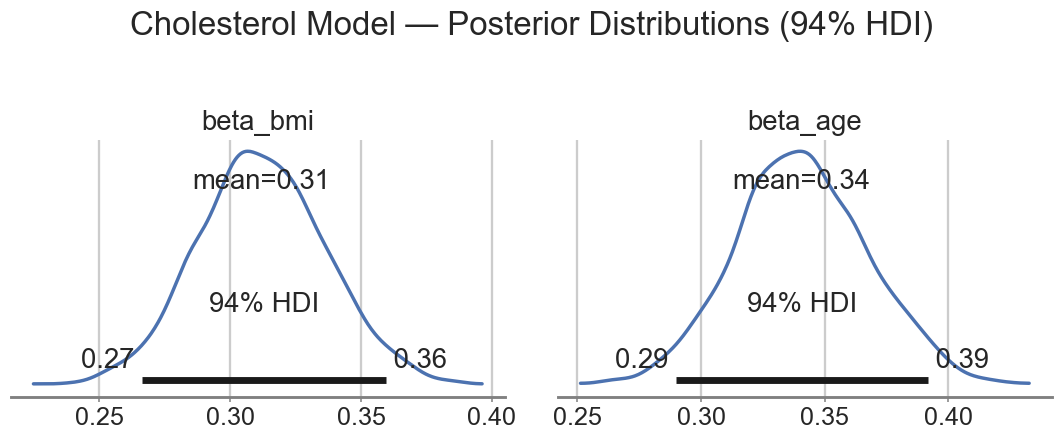

In [25]:
az.plot_posterior(trace_chol,
                  var_names=["beta_bmi", "beta_age"],
                  hdi_prob=0.94, figsize=(10, 4))
plt.suptitle("Cholesterol Model — Posterior Distributions (94% HDI)", y=1.02)
plt.tight_layout()
plt.show()

### Observations and Conclusion: Cholesterol Model

- Both BMI and age have clearly positive posterior coefficients in the ordered logistic model (`beta_bmi ≈ 0.312`, `beta_age ≈ 0.341`).
- Their intervals stay well above zero, so the model supports the idea that higher BMI and older age are associated with worse cholesterol categories.
- The use of an ordered logistic likelihood is important here: it shows that different nodes in a Bayesian Network can use different conditional distributions depending on the type of variable.

**Conclusion.** This local conditional model is coherent with the theory in the report: a Bayesian Network is not restricted to Gaussian nodes, and ordinal outcomes can be handled with their own appropriate conditional model.


## 9. Conditional Model for Cardiovascular Disease (`cardio`)

The final node in the network is `cardio`, which represents the presence or absence of cardiovascular disease. Since this variable is binary, it is modelled using a Bernoulli distribution with a logistic link.

According to the proposed DAG, the direct parents of `cardio` are:

- `ap_hi`,
- `ap_lo`,
- `cholesterol`,
- `gluc`,
- `age`,
- `gender`.

We therefore specify the model through a linear predictor on the log-odds scale:

$$
\text{logit}(p_i)
=
\alpha
+ \beta_{\text{ap\_hi}}\cdot \text{ap\_hi}_i
+ \beta_{\text{ap\_lo}}\cdot \text{ap\_lo}_i
+ \beta_{\text{chol}}\cdot \text{cholesterol}_i
+ \beta_{\text{gluc}}\cdot \text{gluc}_i
+ \beta_{\text{age}}\cdot \text{age}_i
+ \beta_{\text{gender}}\cdot \text{gender}_i
$$

where $$(p_i = P(cardio_i = 1 | parents_i))$$ denotes the conditional probability that individual \(i\) has cardiovascular disease.
And $parents_i$ = $ap$ _ $hi_i$, $ap$ _ $lo_i$, $cholesterol_i$, $gluc_i$, $age_i$, $gender_i$.
The observed outcome is then modelled as

$$
\text{cardio}_i \sim \text{Bernoulli}(p_i).
$$


This model allows us to estimate how blood pressure, cholesterol, glucose, age, and gender contribute directly to the probability of cardiovascular disease, conditional on the structure encoded in the DAG.

In simple terms, the logit link transforms a probability between 0 and 1 into a scale where the effects of the predictors can be modelled linearly. A positive coefficient means that higher values of the corresponding predictor increase the probability of cardiovascular disease, while a negative coefficient means the opposite.

### Prior specification

For the cardiovascular disease model, priors are assigned to the intercept and to each regression coefficient on the log-odds scale.

The intercept `alpha` is given a `Normal(0,1)` prior. Since the predictors are centred or standardised, this reflects the belief that the baseline log-odds of cardiovascular disease should lie in a reasonable range without being overly restrictive.

The coefficient `beta_ap_hi` is assigned a `Normal(0.5,0.5)` prior, centred above zero to reflect the prior expectation that higher systolic blood pressure increases cardiovascular risk.

The coefficients `beta_ap_lo`, `beta_chol`, `beta_gluc`, and `beta_age` are also assigned priors centred slightly above zero, reflecting prior knowledge that higher diastolic pressure, cholesterol, glucose, and age are generally associated with greater cardiovascular risk. Their prior standard deviation remains wide enough to let the data substantially update these beliefs.

The coefficient `beta_gender` is assigned a `Normal(0,0.5)` prior, expressing prior uncertainty about both the direction and magnitude of the gender effect.

Overall, these priors are weakly informative and mildly directional where medical knowledge suggests a positive relationship with disease risk.

In [26]:
# Use float version of cholesterol for outcome model
chol_z, chol_mu, chol_sd = standardise(df_model["cholesterol"].astype(float))

with pm.Model() as model_cardio:
    alpha        = pm.Normal("alpha",        mu=0,   sigma=1)
    beta_ap_hi   = pm.Normal("beta_ap_hi",   mu=0.5, sigma=0.5)  # positive prior: BP→CVD
    beta_ap_lo   = pm.Normal("beta_ap_lo",   mu=0.2, sigma=0.5)
    beta_chol    = pm.Normal("beta_chol",    mu=0.3, sigma=0.5)  # positive prior: chol→CVD
    beta_gluc    = pm.Normal("beta_gluc",    mu=0.2, sigma=0.5)
    beta_age     = pm.Normal("beta_age",     mu=0.4, sigma=0.5)  # positive prior: age→CVD
    beta_gender  = pm.Normal("beta_gender",  mu=0,   sigma=0.5)

    logit_p = (
        alpha
        + beta_ap_hi  * ap_hi_z
        + beta_ap_lo  * ap_lo_z
        + beta_chol   * chol_z
        + beta_gluc   * gluc_z
        + beta_age    * age_z
        + beta_gender * gender_c
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    cardio_obs_var = pm.Bernoulli("cardio_obs", p=p, observed=cardio_obs)

    trace_cardio = pm.sample(
        draws=2000, tune=1500, chains=2, cores=1,
        target_accept=0.92, random_seed=RANDOM_SEED,
        progressbar=True, return_inferencedata=True,
    )

print(az.summary(
    trace_cardio,
    var_names=["alpha","beta_ap_hi","beta_ap_lo","beta_chol",
               "beta_gluc","beta_age","beta_gender"],
    round_to=3
))

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_ap_hi, beta_ap_lo, beta_chol, beta_gluc, beta_age, beta_gender]


Output()

Sampling 2 chains for 1_500 tune and 2_000 draw iterations (3_000 + 4_000 draws total) took 98 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       -0.011  0.026  -0.059    0.037      0.000    0.000  6501.502   
beta_ap_hi   0.912  0.043   0.832    0.990      0.001    0.001  3950.645   
beta_ap_lo   0.133  0.039   0.061    0.210      0.001    0.001  4212.390   
beta_chol    0.330  0.030   0.275    0.389      0.000    0.000  4013.303   
beta_gluc   -0.020  0.029  -0.074    0.037      0.000    0.000  4983.669   
beta_age     0.347  0.027   0.296    0.396      0.000    0.000  6570.146   
beta_gender -0.035  0.053  -0.136    0.065      0.001    0.001  5699.395   

             ess_tail  r_hat  
alpha        2740.624  1.003  
beta_ap_hi   3517.670  1.000  
beta_ap_lo   3247.894  1.000  
beta_chol    3104.195  1.000  
beta_gluc    3562.898  1.000  
beta_age     2605.294  1.000  
beta_gender  3096.218  1.000  


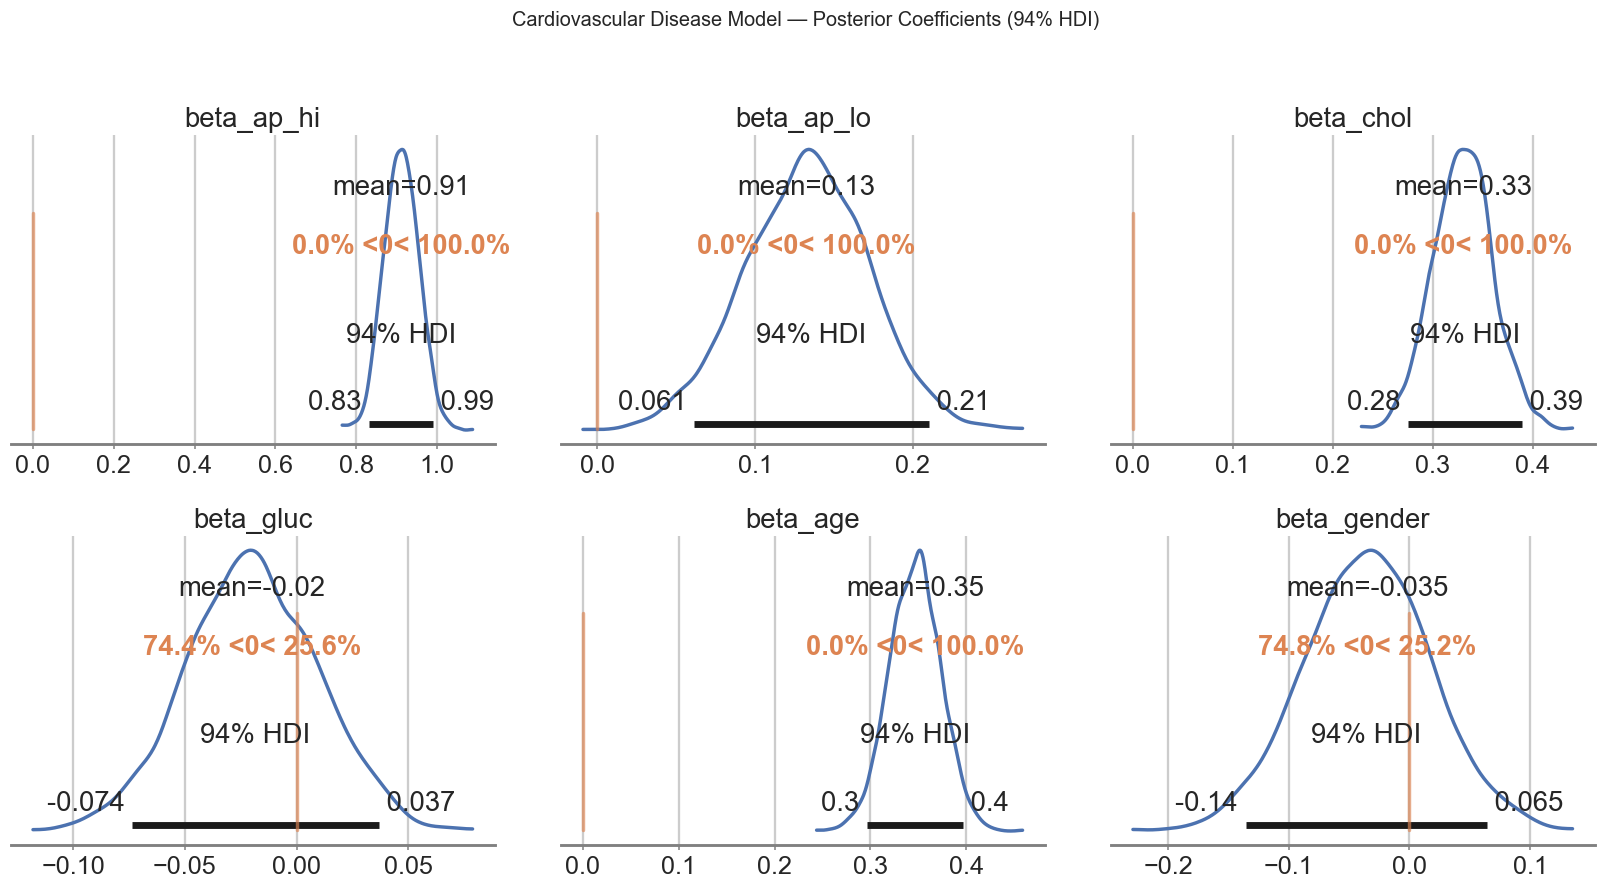

In [27]:
coef_vars = ["beta_ap_hi","beta_ap_lo","beta_chol",
             "beta_gluc","beta_age","beta_gender"]

az.plot_posterior(trace_cardio, var_names=coef_vars,
                  hdi_prob=0.94, figsize=(15, 8),
                  ref_val=0)
plt.suptitle("Cardiovascular Disease Model — Posterior Coefficients (94% HDI)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

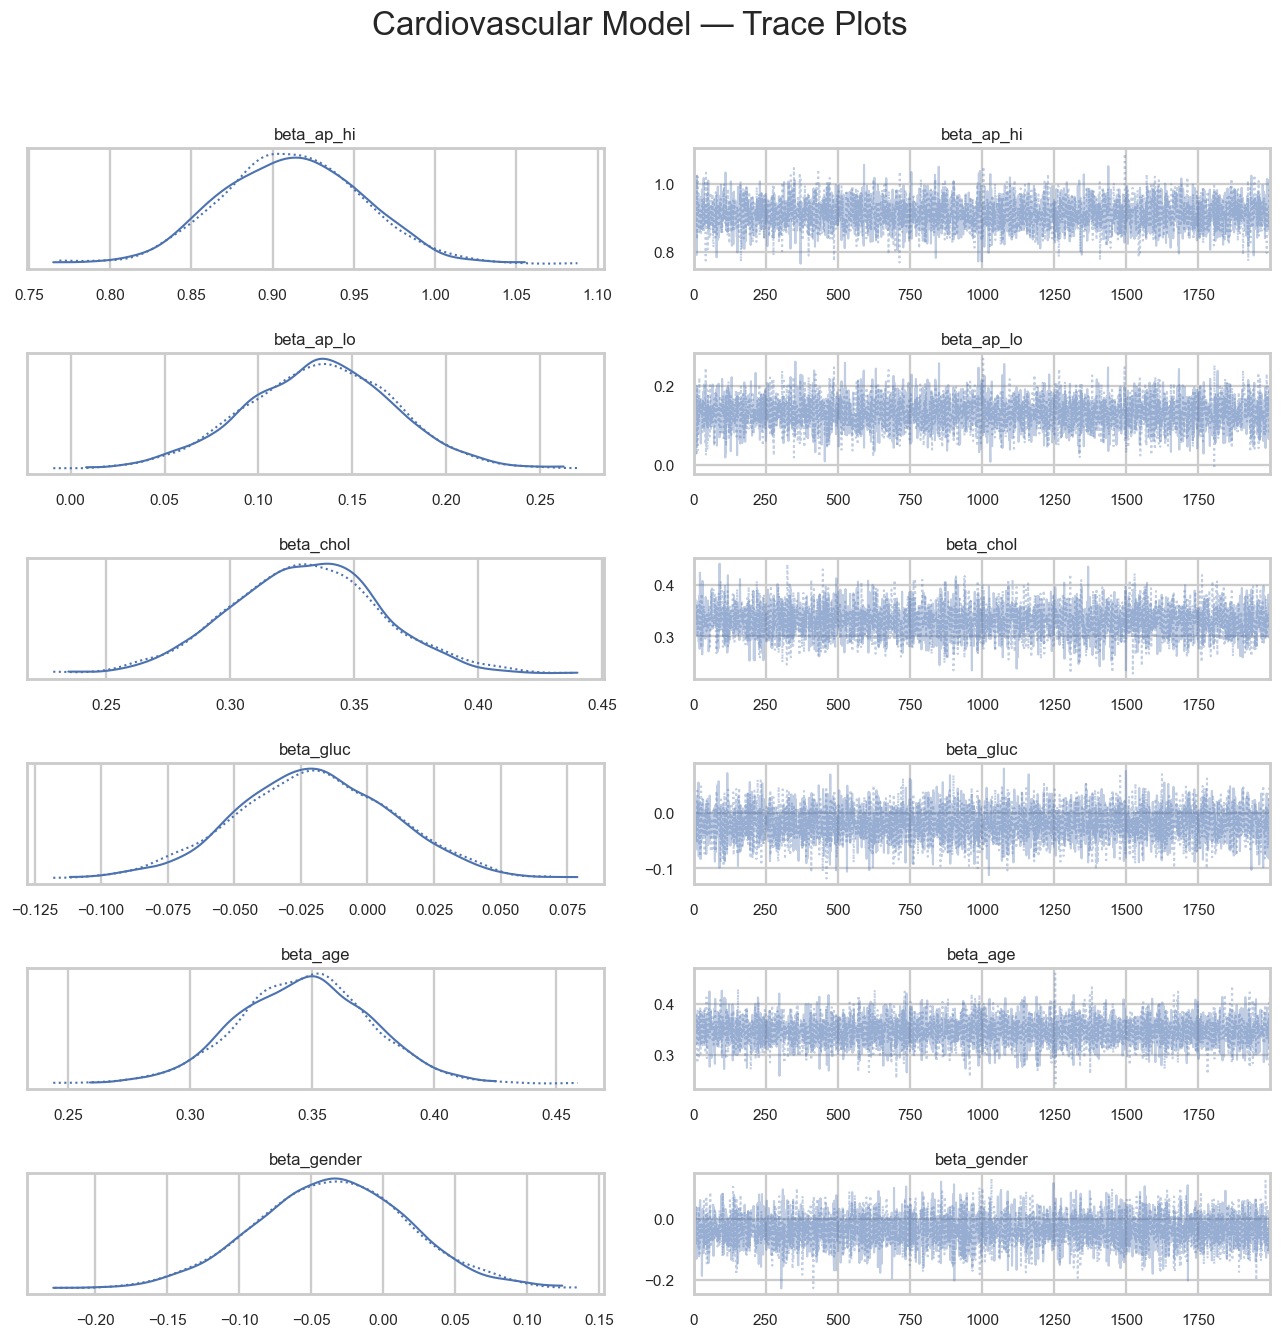

In [28]:
az.plot_trace(trace_cardio, var_names=coef_vars)
plt.suptitle("Cardiovascular Model — Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### Observations and Conclusion: Cardiovascular Disease Model

- Systolic blood pressure is the strongest direct predictor in the final logistic model (`beta_ap_hi ≈ 0.912`, 94% HDI roughly `[0.832, 0.990]`).
- Diastolic pressure is also positive, but much smaller (`beta_ap_lo ≈ 0.133`).
- Cholesterol and age both have clearly positive direct effects (`beta_chol ≈ 0.330`, `beta_age ≈ 0.347`).
- `gluc` and `gender` are close to zero and their credible intervals include zero, so this fitted model does not give strong evidence of an additional direct effect from those variables once the others are already included.

**Conclusion.** In this fitted network, the main direct drivers of cardiovascular disease are systolic pressure, cholesterol, and age, with systolic pressure standing out most strongly. This is why the upstream models for BMI, smoking, and age matter: they influence risk largely through these intermediate nodes.


## 10. MCMC Diagnostics

At this point we have fitted the separate conditional models that make up the Bayesian Network.

Before interpreting them, we should check whether the MCMC algorithm behaved well. In practice, we focus on three standard diagnostics:

- `R-hat`: values close to 1 indicate convergence across chains,
- `ESS`: effective sample size should be reasonably large,
- divergences: ideally there should be none.

We consider R-hat, effective sample size (ESS), and divergences because they capture three complementary aspects of MCMC quality: convergence between chains, the amount of usable posterior information, and possible numerical or geometric problems during sampling. Together, they provide a practical check that posterior summaries can be interpreted with reasonable confidence.

In [29]:
model_registry = {
    "BMI": (trace_bmi,    ["alpha","beta_weight","beta_height","beta_alco","beta_active","sigma"]),
    "ap_hi": (trace_ap_hi, ["alpha","beta_bmi","beta_age","beta_smoke","sigma"]),
    "ap_lo": (trace_ap_lo, ["alpha","beta_bmi","beta_age","sigma"]),
    "Cholesterol": (trace_chol,   ["beta_bmi","beta_age"]),
    "Cardio": (trace_cardio, coef_vars),
}

diagnostic_rows = []
for model_name, (trace, var_names) in model_registry.items():
    summary = az.summary(trace, var_names=var_names)
    max_rhat = summary["r_hat"].max()
    min_ess  = summary[["ess_bulk","ess_tail"]].min().min()
    n_divergences = int(trace.sample_stats["diverging"].values.sum())
    diagnostic_rows.append({
        "Model": model_name,
        "Max R-hat": round(max_rhat, 4),
        "Min ESS": int(min_ess),
        "Divergences": n_divergences,
        "Status": "✅ OK" if max_rhat < 1.01 and min_ess > 400 and n_divergences == 0
                  else "⚠️ Check",
    })

diag_df = pd.DataFrame(diagnostic_rows)
print("=" * 60)
print("MCMC DIAGNOSTICS SUMMARY")
print("=" * 60)
print(diag_df.to_string(index=False))

MCMC DIAGNOSTICS SUMMARY
      Model  Max R-hat  Min ESS  Divergences Status
        BMI        1.0     1766            0   ✅ OK
      ap_hi        1.0     1990            0   ✅ OK
      ap_lo        1.0     1976            0   ✅ OK
Cholesterol        1.0     2092            0   ✅ OK
     Cardio        1.0     2605            0   ✅ OK


### Observations and Conclusion: MCMC Diagnostics

- All models have `R-hat` essentially equal to 1.
- All minimum ESS values are comfortably above the simple threshold used in the notebook.
- No divergences were reported in any of the fitted models.

**Conclusion.** These diagnostics support the numerical stability of the posterior summaries, so the interpretation of the local conditional models is reasonably well supported by the MCMC output.


## 11. One Combined View of the Network Coefficients

The next figure puts together the main posterior coefficients from all conditional models.

This is useful because it gives a compact summary of the full Bayesian Network: each interval represents one direct relationship encoded by the graph.


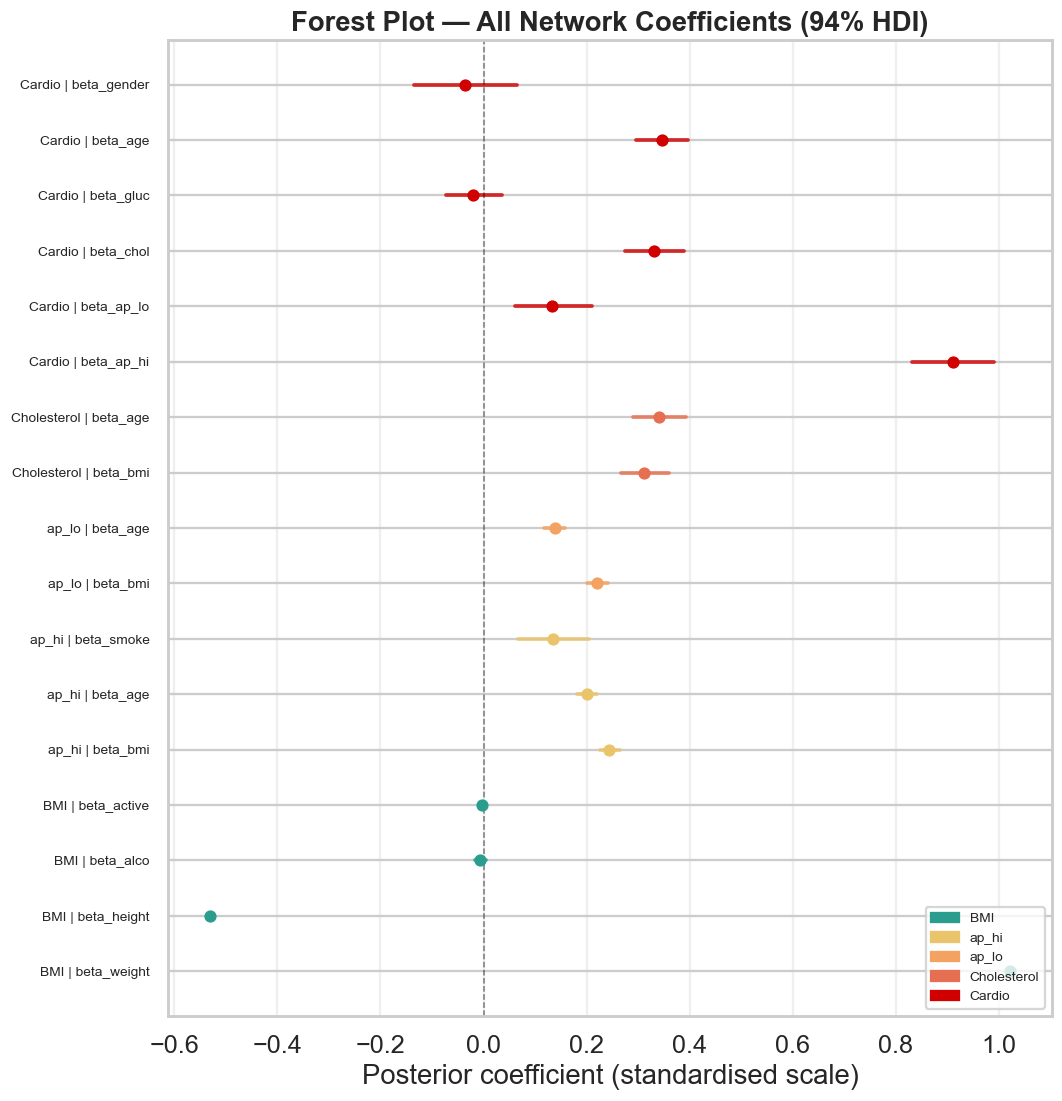

In [30]:
def extract_posterior_stats(trace, var_names, hdi_prob=0.94):
    """Extract mean and HDI bounds for a list of scalar variables."""
    rows = []
    for vn in var_names:
        samples = trace.posterior[vn].values.flatten()
        mean = float(samples.mean())
        hdi = az.hdi(samples, hdi_prob=hdi_prob)
        rows.append({"var": vn, "mean": mean, "lo": float(hdi[0]), "hi": float(hdi[1])})
    return pd.DataFrame(rows)

forest_data = []
for model_name, (trace, var_names) in model_registry.items():
    # Exclude intercept and sigma for readability
    coef_only = [v for v in var_names if v not in ("alpha","sigma","cutpoints")]
    if not coef_only:
        continue
    stats = extract_posterior_stats(trace, coef_only)
    stats["model"] = model_name
    forest_data.append(stats)

forest_df = pd.concat(forest_data, ignore_index=True)
forest_df["label"] = forest_df["model"] + " | " + forest_df["var"]

fig, ax = plt.subplots(figsize=(10, len(forest_df) * 0.55 + 1))

colors = {
    "BMI": "#2A9D8F", "ap_hi": "#E9C46A", "ap_lo": "#F4A261",
    "Cholesterol": "#E76F51", "Cardio": "#D00000",
}

for i, row in forest_df.iterrows():
    col = colors.get(row["model"], "#555")
    ax.plot([row["lo"], row["hi"]], [i, i], color=col, lw=2.5, alpha=0.8)
    ax.plot(row["mean"], i, "o", color=col, ms=7, zorder=5)

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_yticks(range(len(forest_df)))
ax.set_yticklabels(forest_df["label"], fontsize=9)
ax.set_xlabel("Posterior coefficient (standardised scale)")
ax.set_title("Forest Plot — All Network Coefficients (94% HDI)", fontweight="bold")

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

This forest plot summarises the posterior means and 94% HDIs of all regression coefficients in the network. Intervals far from zero indicate stronger evidence of a direct conditional association in the corresponding local model, while intervals overlapping zero suggest weaker or more uncertain effects.

## 12. Interventional Questions

One attractive feature of a Bayesian Network is that, once the graph and the conditional models are specified, we can propagate changes through the system.

Here we move from descriptive questions such as

- `P(cardio | smoke = 1)`

to intervention-style questions such as

- `P(cardio | do(smoke = 1))`.

The idea is simple: we force one variable to take a chosen value, propagate the consequences through the graph, and then observe the resulting distribution of cardiovascular risk.

Important note:

- the intervention values used in the code are on the **prepared scale** from Section 4,
- for example, `BMI = -1 SD` means one standard deviation below the sample mean, not a literal BMI value in original units.


In [31]:
def propagate_network(
    n_patients=2000,
    n_posterior=500,
    intervention=None,   # dict: {"var_name": value_in_standardised_scale}
    seed=0,
):
    """
    Monte Carlo forward propagation through the fitted DAG.

    For each posterior draw and each simulated patient:
      1. Sample root node values from observed marginals
      2. Apply structural equations in topological order
      3. Apply interventions (do-operator) by fixing variables
      4. Return P(cardio=1) distribution across draws
    """
    rng_mc = np.random.default_rng(seed)
    intervention = intervention or {}

    # Extract posterior samples (flatten chains) 
    def get_samples(trace, var):
        return trace.posterior[var].values.flatten()

    bmi_alpha   = get_samples(trace_bmi, "alpha")
    bmi_bw      = get_samples(trace_bmi, "beta_weight")
    bmi_bh      = get_samples(trace_bmi, "beta_height")
    bmi_balco   = get_samples(trace_bmi, "beta_alco")
    bmi_bact    = get_samples(trace_bmi, "beta_active")
    bmi_sigma   = get_samples(trace_bmi, "sigma")

    aphi_alpha  = get_samples(trace_ap_hi, "alpha")
    aphi_bbmi   = get_samples(trace_ap_hi, "beta_bmi")
    aphi_bage   = get_samples(trace_ap_hi, "beta_age")
    aphi_bsmoke = get_samples(trace_ap_hi, "beta_smoke")
    aphi_sigma  = get_samples(trace_ap_hi, "sigma")

    aplo_alpha  = get_samples(trace_ap_lo, "alpha")
    aplo_bbmi   = get_samples(trace_ap_lo, "beta_bmi")
    aplo_bage   = get_samples(trace_ap_lo, "beta_age")
    aplo_sigma  = get_samples(trace_ap_lo, "sigma")

    chol_bbmi   = get_samples(trace_chol, "beta_bmi")
    chol_bage   = get_samples(trace_chol, "beta_age")

    card_alpha   = get_samples(trace_cardio, "alpha")
    card_baphi   = get_samples(trace_cardio, "beta_ap_hi")
    card_baplo   = get_samples(trace_cardio, "beta_ap_lo")
    card_bchol   = get_samples(trace_cardio, "beta_chol")
    card_bgluc   = get_samples(trace_cardio, "beta_gluc")
    card_bage    = get_samples(trace_cardio, "beta_age")
    card_bgender = get_samples(trace_cardio, "beta_gender")

    # Different fitted submodels can expose different posterior sample counts.
    # Limit indexing to the common available range across all parameter arrays.
    sample_sizes = [
        len(bmi_alpha), len(bmi_bw), len(bmi_bh), len(bmi_balco), len(bmi_bact), len(bmi_sigma),
        len(aphi_alpha), len(aphi_bbmi), len(aphi_bage), len(aphi_bsmoke), len(aphi_sigma),
        len(aplo_alpha), len(aplo_bbmi), len(aplo_bage), len(aplo_sigma),
        len(chol_bbmi), len(chol_bage),
        len(card_alpha), len(card_baphi), len(card_baplo), len(card_bchol),
        len(card_bgluc), len(card_bage), len(card_bgender),
    ]
    n_available = min(sample_sizes)
    n_post = min(n_posterior, n_available)
    idx = rng_mc.choice(n_available, size=n_post, replace=False)

    p_cardio_list = []

    for i in idx:
        # Simulate root nodes from observed marginals 
        age_s    = rng_mc.choice(age_z,    size=n_patients)
        weight_s = rng_mc.choice(weight_z, size=n_patients)
        height_s = rng_mc.choice(height_z, size=n_patients)
        alco_s   = rng_mc.choice(alco_c,   size=n_patients)
        active_s = rng_mc.choice(active_c, size=n_patients)
        smoke_s  = rng_mc.choice(smoke_c,  size=n_patients)
        gender_s = rng_mc.choice(gender_c, size=n_patients)
        gluc_s   = rng_mc.choice(gluc_z,   size=n_patients)

        # Intervention: do(smoke = value) 
        if "smoke" in intervention:
            smoke_s = np.full(n_patients, intervention["smoke"])
        if "active" in intervention:
            active_s = np.full(n_patients, intervention["active"])
        if "bmi" in intervention:
            # Will override computed BMI below
            bmi_intervened = np.full(n_patients, intervention["bmi"])

        # Structural equation: BMI 
        bmi_s = (
            bmi_alpha[i]
            + bmi_bw[i]   * weight_s
            + bmi_bh[i]   * height_s
            + bmi_balco[i]* alco_s
            + bmi_bact[i] * active_s
            + rng_mc.normal(0, bmi_sigma[i], size=n_patients)
        )
        if "bmi" in intervention:
            bmi_s = bmi_intervened

        # Structural equation: ap_hi 
        ap_hi_s = (
            aphi_alpha[i]
            + aphi_bbmi[i]   * bmi_s
            + aphi_bage[i]   * age_s
            + aphi_bsmoke[i] * smoke_s
            + rng_mc.normal(0, aphi_sigma[i], size=n_patients)
        )

        # Structural equation: ap_lo 
        ap_lo_s = (
            aplo_alpha[i]
            + aplo_bbmi[i] * bmi_s
            + aplo_bage[i] * age_s
            + rng_mc.normal(0, aplo_sigma[i], size=n_patients)
        )

        # Structural equation: cholesterol (continuous proxy) 
        chol_s = chol_bbmi[i] * bmi_s + chol_bage[i] * age_s

        # Outcome: cardio
        logit_p = (
            card_alpha[i]
            + card_baphi[i]   * ap_hi_s
            + card_baplo[i]   * ap_lo_s
            + card_bchol[i]   * chol_s
            + card_bgluc[i]   * gluc_s
            + card_bage[i]    * age_s
            + card_bgender[i] * gender_s
        )
        p_s = 1 / (1 + np.exp(-logit_p))
        p_cardio_list.append(p_s.mean())

    return np.array(p_cardio_list)

print("Propagation function defined.")

Propagation function defined.


In [32]:
print("Running interventional queries (this may take 1–2 minutes)...")

# Observational baseline 
p_baseline = propagate_network(seed=10)

# do(smoke = 1): everyone smokes 
smoke_mean = float(df_model["smoke"].mean())
p_smoke_on  = propagate_network(intervention={"smoke":  (1 - smoke_mean)}, seed=11)
p_smoke_off = propagate_network(intervention={"smoke": (0 - smoke_mean)},  seed=12)

# do(active = 1): everyone is physically active 
active_mean = float(df_model["active"].mean())
p_active_on  = propagate_network(intervention={"active": (1 - active_mean)}, seed=13)
p_active_off = propagate_network(intervention={"active": (0 - active_mean)}, seed=14)

# do(BMI = low_value): reduce BMI by 1 SD 
p_bmi_low  = propagate_network(intervention={"bmi": -1.0}, seed=15)
p_bmi_high = propagate_network(intervention={"bmi":  1.0}, seed=16)

print("Done.")

Running interventional queries (this may take 1–2 minutes)...
Done.


In [33]:
scenarios = {
    "Baseline":           p_baseline,
    "do(smoke=1)": p_smoke_on,
    "do(smoke=0)": p_smoke_off,
    "do(active=1)": p_active_on,
    "do(active=0)": p_active_off,
    "do(BMI = −1 SD)": p_bmi_low,
    "do(BMI = +1 SD)": p_bmi_high,
}

print(f"{'Scenario':<22} {'Mean P(CVD)':>12} {'95% CI':>22} {'vs Baseline':>14}")
print("-" * 74)
baseline_mean = p_baseline.mean()
for name, p_arr in scenarios.items():
    ci = np.quantile(p_arr, [0.025, 0.975])
    diff = p_arr.mean() - baseline_mean
    print(f"{name:<22} {p_arr.mean():>12.4f} [{ci[0]:.4f}, {ci[1]:.4f}]  "
          f"{diff:>+.4f}")

Scenario                Mean P(CVD)                 95% CI    vs Baseline
--------------------------------------------------------------------------
Baseline                     0.4987 [0.4841, 0.5124]  +0.0000
do(smoke=1)                  0.5206 [0.5032, 0.5388]  +0.0219
do(smoke=0)                  0.4960 [0.4810, 0.5112]  -0.0026
do(active=1)                 0.4982 [0.4842, 0.5151]  -0.0005
do(active=0)                 0.4983 [0.4843, 0.5142]  -0.0003
do(BMI = −1 SD)              0.4282 [0.4143, 0.4433]  -0.0705
do(BMI = +1 SD)              0.5698 [0.5545, 0.5861]  +0.0711


### Observations and Conclusion: Interventions

- The observational baseline is about `0.499`, so the fitted network reproduces a roughly balanced cardiovascular-risk level in the sample.
- Setting everyone to smoke increases mean risk to about `0.521`, whereas setting everyone to non-smoking only lowers it slightly relative to baseline (`0.496`). In this DAG that makes sense because smoking enters mainly through the `ap_hi` equation rather than as a direct parent of `cardio`.
- The physical-activity interventions barely move the final risk. This is coherent with the earlier BMI model, where `active` had an estimated coefficient very close to zero once weight and height were already included.
- The BMI interventions are by far the most influential: moving BMI down by 1 SD lowers mean risk to about `0.428`, while moving BMI up by 1 SD raises it to about `0.570`.

**Conclusion.** In this fitted Bayesian Network, BMI is the strongest lever among the interventions considered. Smoking matters, but more modestly; physical activity has almost no effect here because the estimated local pathways from `active` to downstream risk are weak in this particular specification.


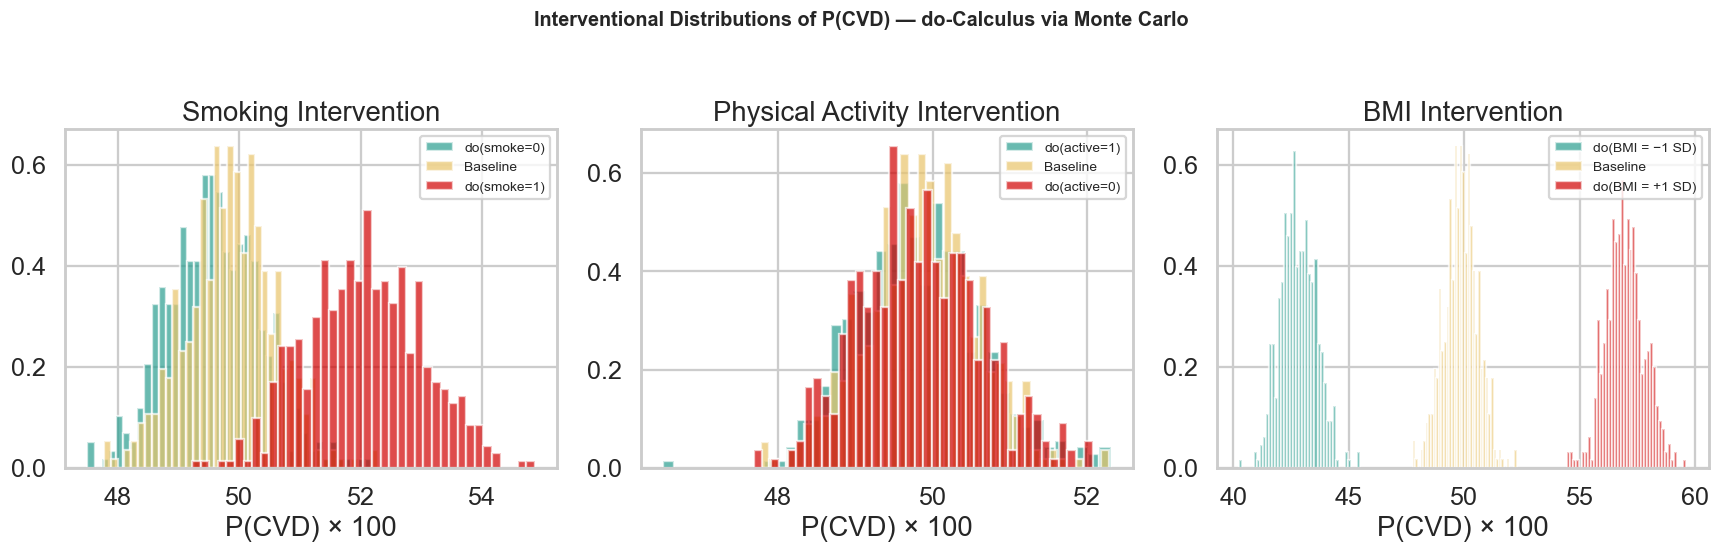

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

# Smoking intervention 
axes[0].hist(p_smoke_off * 100, bins=40, alpha=0.7, color="#2A9D8F",
             label="do(smoke=0)", density=True)
axes[0].hist(p_baseline  * 100, bins=40, alpha=0.7, color="#E9C46A",
             label="Baseline",   density=True)
axes[0].hist(p_smoke_on  * 100, bins=40, alpha=0.7, color="#D00000",
             label="do(smoke=1)", density=True)
axes[0].set_title("Smoking Intervention")
axes[0].set_xlabel("P(CVD) × 100")
axes[0].legend(fontsize=9)

# Activity intervention 
axes[1].hist(p_active_on  * 100, bins=40, alpha=0.7, color="#2A9D8F",
             label="do(active=1)", density=True)
axes[1].hist(p_baseline   * 100, bins=40, alpha=0.7, color="#E9C46A",
             label="Baseline",    density=True)
axes[1].hist(p_active_off * 100, bins=40, alpha=0.7, color="#D00000",
             label="do(active=0)", density=True)
axes[1].set_title("Physical Activity Intervention")
axes[1].set_xlabel("P(CVD) × 100")
axes[1].legend(fontsize=9)

# BMI intervention 
axes[2].hist(p_bmi_low  * 100, bins=40, alpha=0.7, color="#2A9D8F",
             label="do(BMI = −1 SD)", density=True)
axes[2].hist(p_baseline * 100, bins=40, alpha=0.7, color="#E9C46A",
             label="Baseline",       density=True)
axes[2].hist(p_bmi_high * 100, bins=40, alpha=0.7, color="#D00000",
             label="do(BMI = +1 SD)", density=True)
axes[2].set_title("BMI Intervention")
axes[2].set_xlabel("P(CVD) × 100")
axes[2].legend(fontsize=9)

fig.suptitle("Interventional Distributions of P(CVD) — do-Calculus via Monte Carlo",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 13. Posterior Predictive Check

A useful way to assess the fit of a Bayesian model is to check whether it can reproduce key features of the observed data.

Here, we focus on one simple and intuitive quantity: the overall prevalence of cardiovascular disease in the sample. Using the fitted posterior distribution of the final outcome model, we simulate new `cardio` values and compute the prevalence in these replicated datasets. We then compare the simulated prevalences with the prevalence actually observed in the data.

If the model fits reasonably well, the observed prevalence should fall within the range of plausible replicated values generated by the model.

Sampling: [cardio_obs]


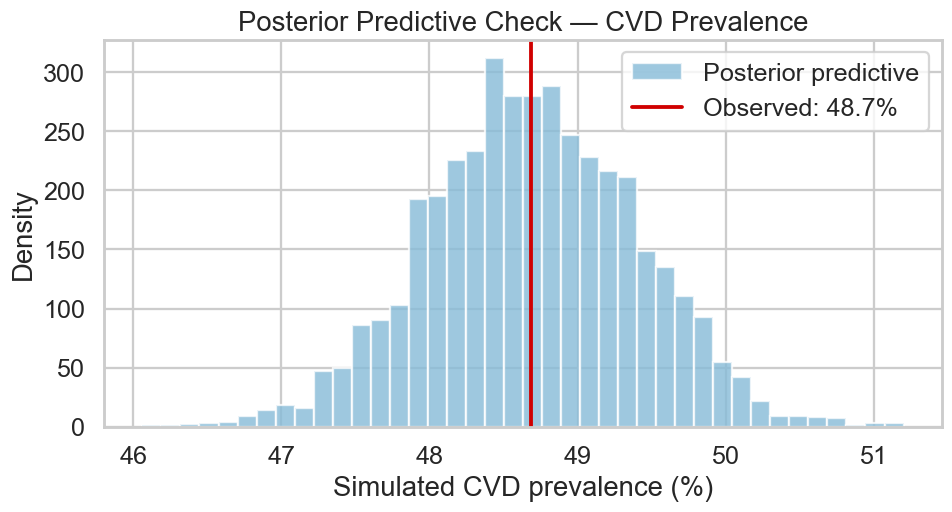

Observed CVD prevalence:              48.69%
Posterior predictive mean:            48.70%
Posterior predictive 95% CI:  [47.31%, 50.06%]


In [35]:
with model_cardio:
    ppc = pm.sample_posterior_predictive(
        trace_cardio, random_seed=RANDOM_SEED, progressbar=False
    )

# Simulated prevalence across posterior draws
ppc_prev = ppc.posterior_predictive["cardio_obs"].values.mean(axis=-1).flatten()
obs_prev = cardio_obs.mean()

plt.figure(figsize=(9, 5))
plt.hist(ppc_prev * 100, bins=40, color="#86BBD8", edgecolor="white",
         alpha=0.8, label="Posterior predictive")
plt.axvline(obs_prev * 100, color="#D00000", linewidth=2.5,
            label=f"Observed: {obs_prev*100:.1f}%")
plt.xlabel("Simulated CVD prevalence (%)")
plt.ylabel("Density")
plt.title("Posterior Predictive Check — CVD Prevalence")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Observed CVD prevalence:              {obs_prev*100:.2f}%")
print(f"Posterior predictive mean:            {ppc_prev.mean()*100:.2f}%")
print(f"Posterior predictive 95% CI:  [{np.quantile(ppc_prev, 0.025)*100:.2f}%, "
      f"{np.quantile(ppc_prev, 0.975)*100:.2f}%]")

### Observations and Conclusion: Posterior Predictive Check

- The observed prevalence is `48.69%` and the posterior predictive mean is `48.70%`.
- The observed value lies well inside the posterior predictive 95% interval `[47.31%, 50.06%]`.

**Conclusion.** For this aggregate summary, the final cardiovascular outcome model fits the data very well. That does not prove the whole network is perfect, but it is an important consistency check before interpreting the interventional results.


## 14. Final Summary of the Real Example

The next dashboard gathers the main results of the real-data example in one place:

- the most important posterior coefficients,
- the intervention comparison,
- and two visual summaries of how some relationships behave.

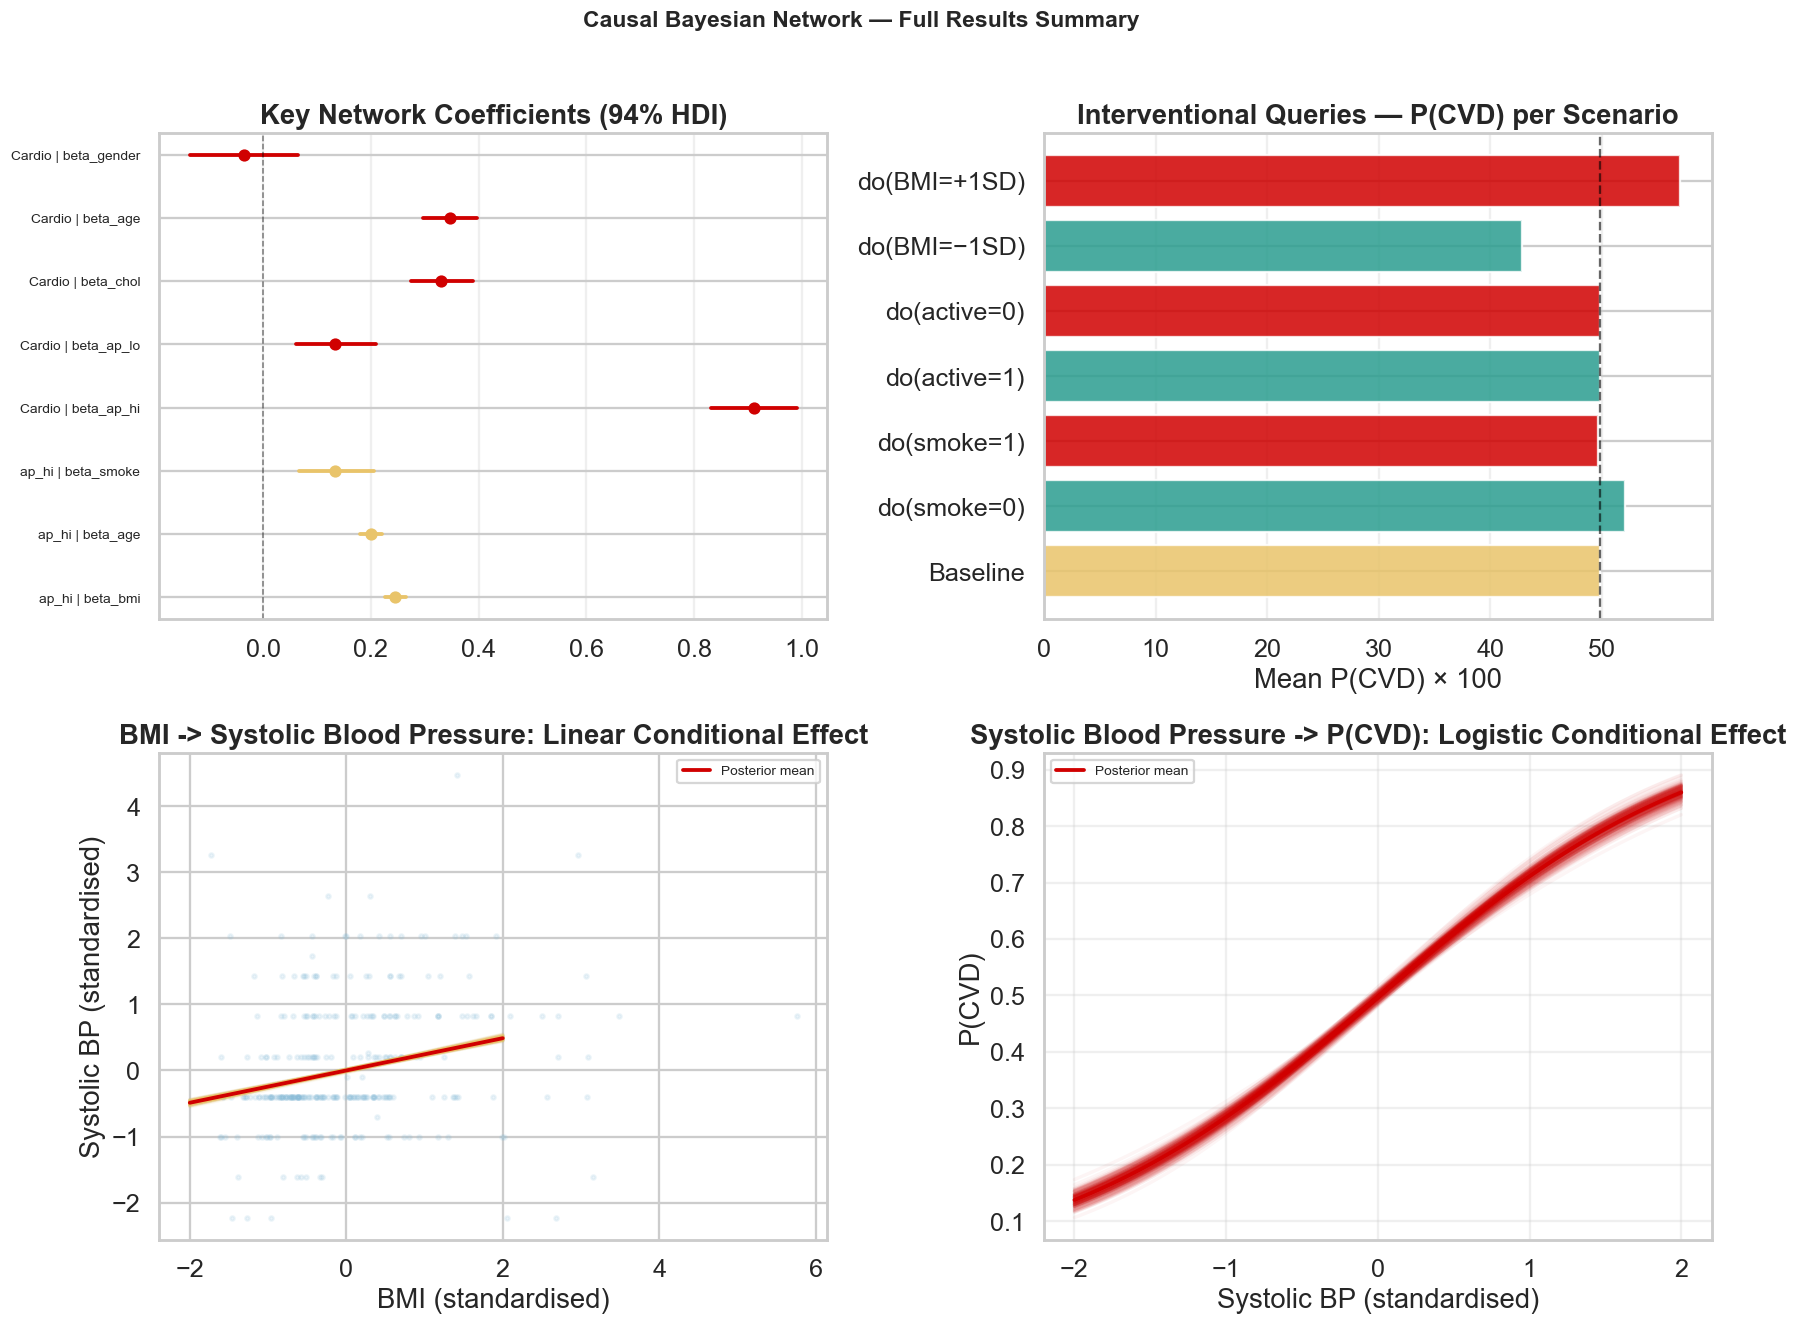

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Forest plot (key coefficients only) 
key_vars = [
    ("ap_hi",   "beta_bmi",    "#E9C46A"),
    ("ap_hi",   "beta_age",    "#E9C46A"),
    ("ap_hi",   "beta_smoke",  "#E9C46A"),
    ("Cardio",  "beta_ap_hi",  "#D00000"),
    ("Cardio",  "beta_ap_lo",  "#D00000"),
    ("Cardio",  "beta_chol",   "#D00000"),
    ("Cardio",  "beta_age",    "#D00000"),
    ("Cardio",  "beta_gender", "#D00000"),
]
ax = axes[0, 0]
traces_map = {"ap_hi": trace_ap_hi, "Cardio": trace_cardio}
for i, (model_n, var_n, col) in enumerate(key_vars):
    samples = traces_map[model_n].posterior[var_n].values.flatten()
    hdi = az.hdi(samples, hdi_prob=0.94)
    ax.plot([hdi[0], hdi[1]], [i, i], color=col, lw=2.5)
    ax.plot(samples.mean(), i, "o", color=col, ms=7, zorder=5)
ax.axvline(0, color="black", ls="--", lw=1, alpha=0.5)
ax.set_yticks(range(len(key_vars)))
ax.set_yticklabels([f"{m} | {v}" for m, v, _ in key_vars], fontsize=9)
ax.set_title("Key Network Coefficients (94% HDI)", fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# Panel 2: Intervention comparison bar chart 
ax2 = axes[0, 1]
scenario_labels = ["Baseline", "do(smoke=0)", "do(smoke=1)",
                   "do(active=1)", "do(active=0)",
                   "do(BMI=−1SD)", "do(BMI=+1SD)"]
scenario_means  = [s.mean() * 100 for s in scenarios.values()]
scenario_colors = ["#E9C46A","#2A9D8F","#D00000",
                   "#2A9D8F","#D00000","#2A9D8F","#D00000"]
bars = ax2.barh(scenario_labels, scenario_means, color=scenario_colors,
                edgecolor="white", alpha=0.85)
ax2.axvline(scenario_means[0], color="black", ls="--", lw=1.5, alpha=0.6)
ax2.set_xlabel("Mean P(CVD) × 100")
ax2.set_title("Interventional Queries — P(CVD) per Scenario", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

# Panel 3: BMI → ap_hi posterior predictive 
ax3 = axes[1, 0]
bmi_grid = np.linspace(-2, 2, 100)
alpha_samples = trace_ap_hi.posterior["alpha"].values.flatten()
bbmi_samples  = trace_ap_hi.posterior["beta_bmi"].values.flatten()
n_lines = 150
idx_lines = rng.choice(len(alpha_samples), n_lines, replace=False)
for j in idx_lines:
    ax3.plot(bmi_grid, alpha_samples[j] + bbmi_samples[j] * bmi_grid,
             color="#E9C46A", alpha=0.06)
mean_line = alpha_samples.mean() + bbmi_samples.mean() * bmi_grid
ax3.plot(bmi_grid, mean_line, color="#D00000", lw=2.5, label="Posterior mean")
ax3.scatter(bmi_z[:300], ap_hi_z[:300], alpha=0.15, s=8, color="#86BBD8")
ax3.set_xlabel("BMI (standardised)")
ax3.set_ylabel("Systolic BP (standardised)")
ax3.set_title("BMI -> Systolic Blood Pressure: Linear Conditional Effect", fontweight="bold")
ax3.legend(fontsize=9)

# Panel 4: P(CVD) as a function of ap_hi 
ax4 = axes[1, 1]
ap_hi_grid = np.linspace(-2, 2, 100)
card_alpha_s = trace_cardio.posterior["alpha"].values.flatten()
card_baphi_s = trace_cardio.posterior["beta_ap_hi"].values.flatten()
for j in rng.choice(len(card_alpha_s), 200, replace=False):
    p_j = 1 / (1 + np.exp(-(card_alpha_s[j] + card_baphi_s[j] * ap_hi_grid)))
    ax4.plot(ap_hi_grid, p_j, color="#D00000", alpha=0.04)
p_mean = 1 / (1 + np.exp(-(card_alpha_s.mean() + card_baphi_s.mean() * ap_hi_grid)))
ax4.plot(ap_hi_grid, p_mean, color="#D00000", lw=2.5, label="Posterior mean")
ax4.set_xlabel("Systolic BP (standardised)")
ax4.set_ylabel("P(CVD)")
ax4.set_title("Systolic Blood Pressure -> P(CVD): Logistic Conditional Effect", fontweight="bold")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

fig.suptitle("Causal Bayesian Network — Full Results Summary",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

These two subplots below visualise two different kinds of conditional relationships in the network. The link from BMI to systolic blood pressure is shown as a straight fitted line because `ap_hi` is modelled with a Gaussian regression and a linear predictor. By contrast, the link from systolic blood pressure to cardiovascular disease is shown as a curved probability function because `cardio` is modelled with a Bernoulli likelihood and a logistic link.


## 15. Optional: Save Results

This last section is only for convenience. It saves posterior traces and summary tables so the results can be reused outside the notebook.


In [37]:
# Save all traces as NetCDF (compatible with ArviZ)
az.to_netcdf(trace_bmi,     "trace_bmi.nc")
az.to_netcdf(trace_ap_hi,   "trace_ap_hi.nc")
az.to_netcdf(trace_ap_lo,   "trace_ap_lo.nc")
az.to_netcdf(trace_chol,    "trace_chol.nc")
az.to_netcdf(trace_cardio,  "trace_cardio.nc")

# Save diagnostic summary
diag_df.to_csv("mcmc_diagnostics.csv", index=False)

# Save intervention results
intervention_rows = []
for name, p_arr in scenarios.items():
    ci = np.quantile(p_arr, [0.025, 0.975])
    intervention_rows.append({
        "scenario": name,
        "mean_p_cvd": p_arr.mean(),
        "ci_low": ci[0],
        "ci_high": ci[1],
        "delta_vs_baseline": p_arr.mean() - p_baseline.mean(),
    })
pd.DataFrame(intervention_rows).to_csv("intervention_results.csv", index=False)

print("Saved: trace_bmi.nc, trace_ap_hi.nc, trace_ap_lo.nc, trace_chol.nc,")
print("       trace_cardio.nc, mcmc_diagnostics.csv, intervention_results.csv")

Saved: trace_bmi.nc, trace_ap_hi.nc, trace_ap_lo.nc, trace_chol.nc,
       trace_cardio.nc, mcmc_diagnostics.csv, intervention_results.csv
